# Unified parameter sweep -- every parameter tested in this folder, one coherent run

Consolidates `mu_HEK_multiplicity_sweep.ipynb`, `T_viab_sweep.ipynb`, `noise_viab_sweep.ipynb`
(incl. its 2D `d0`x`noise_viab` section), `D_sequencing_depth_sweep.ipynb`, `diversity_sweep.ipynb`,
`diversity_sweep_adaptive_D.ipynb`, and `deeper_mlp/diversity_sweep_deeper_mlp.ipynb` into ONE
notebook, meant to run unattended overnight.

**Why a single notebook.** Each of those was built independently over time and drifted apart on
values that should have been identical: different baseline `mu` (`25`-`50`), different `rho`
(`1e-3` vs `1e-4`), different `N0`/`N1` ratios (`N0=1e9` fixed in some, `N0=N1*10` in others),
different fixed-`d0` pool sizes (`20,000`/`30,000`/`50,000`/`200,000`) depending on which notebook
you opened. None of that was ever the POINT of any individual sweep -- it was incidental, and it
quietly made cross-notebook comparisons (e.g. "does `T_viab` or `noise_viab` hurt recovery more?")
apples-to-oranges. This notebook fixes ONE shared baseline (section 3) and reuses it in every
section below; only the swept parameter itself, and the population size when `d0` is the thing
being swept, differ from section to section.

**Shared baseline** (section 3): `rho=1e-4`, `mu=10`, `N0=150*N1` (a wet-lab constraint: `N1`
cells transfected must stay at least 150x smaller than `N0` plasmid copies in the prep -- see
`CLAUDE.md` "Etat actuel" 2026-08-24), `D=1e9`, `T_viab=0.8`, `noise_viab=0.5`, fixed-`d0` pool
size `20,000` when `d0` itself isn't the swept variable. `DIVERSITY_GRID` (sections F-I) is capped
at `d0=200,000` by the same `N0=150*N1` constraint (see section 3).

**Two things this run resolves that individual notebooks had left open**:
1. `diversity_sweep_deeper_mlp.ipynb` used `D=5e8`/`noise_viab=3` while claiming to reproduce
   `diversity_sweep.ipynb`'s `D=1e8`/`noise_viab=0.5` -- section I here actually uses the same
   `D_FIXED`/`noise_viab` as section F, so the "shallow MLP" curve in section I is now a genuine
   sanity check against section F, not an apples-to-oranges comparison.
2. Every fixed-`d0` sweep (mu, `T_viab`, `noise_viab` 1D, `D`) now shares ONE pool/`ProtocolV3`
   object (section 5), mutated and restored between sections in sequence -- so a "does `T_viab`
   or `noise_viab` matter more" comparison is now made on the literally identical population,
   not two different random 7-mer draws.

**Part 1 -- viability phase** (1 GT weights -- 2 fixed 50k eval pool -- 3 shared baseline -- 4
shared MLP architectures/trainer -- 5 shared fixed-`d0` pool -- **A** mu sweep -- **B** `T_viab`
sweep -- **C** `noise_viab` sweep (1D) -- **D** `D` sweep -- **E** `noise_viab` x `d0` (2D) --
**F** diversity (`d0`) sweep, `D` fixed -- **G** diversity sweep, `D` adaptive -- **H** shallow vs
deep `ProfileMLP` (`d0` sweep)).

**Part 2 -- selectivity phase** (**I** mu sweep -- **J** `T_sel` sweep -- **K** `noise_sel`
sweep -- **L** `D` sweep, plus a direct viability-vs-selectivity noise comparison): mirrors
sections A/B/C/D on `T_sel`/`noise_sel`/`F_sel`/`J_sel`/`target2` instead of
`T_viab`/`noise_viab`/`F_viab`/`J_viab`/`target1` -- expected noisier, since `target2` compounds
the viability step's own noise with a second independent noise draw and a third NGS read-depth
step (see Part 2's own intro cell).


## 0. Setup


In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Must run before the first `import jax` anywhere -- same convention as every sibling notebook.


In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from flax import nnx
import optax

from sequence_classesV1 import *
from analysisV1 import *
from initialize_weights import load_F_viab_aav9_mlp, load_J_viab_aav9_mlp, NUM_AMINO_ACIDS, NUM_POSITIONS

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Ground truth weights

Real AAV9 `F_viab`/`J_viab`, and `F_sel`/`J_sel` built from the same two permutation keys used
throughout this folder -- constructed for parity with the sibling notebooks but never actually
used below (every section here only sweeps the viability channel, `target1`).


In [3]:
F_viab = load_F_viab_aav9_mlp()
J_viab = load_J_viab_aav9_mlp()

key_F, key_J = jax.random.split(jax.random.key(0), 2)
sigma_F = jax.random.permutation(key_F, NUM_AMINO_ACIDS)
F_sel   = F_viab[sigma_F, :]
sigma_J = jax.random.permutation(key_J, NUM_AMINO_ACIDS)
J_sel   = J_viab[:, :, sigma_J, :][:, :, :, sigma_J]

print(f"F_viab shape: {F_viab.shape}   J_viab shape: {J_viab.shape}")


F_viab shape: (20, 7)   J_viab shape: (7, 7, 20, 20)


## 2. Fixed 50,000-sequence evaluation pool

Same `EVAL_POOL_KEY_SEED=999`/`EVAL_POOL_SIZE=50_000` pair used in every sweep notebook in this
project -- every model trained anywhere below gets evaluated on this SAME population, in addition
to its own section's in-sweep test fold, so top-K recovery is comparable both within a section and
across every section (and every other notebook using this same key).


In [4]:
EVAL_POOL_KEY_SEED = 999   # fixed across every notebook in this project -- reuse this exact value
EVAL_POOL_SIZE     = 50_000

def compute_score_array(seq, F, J, L=NUM_POSITIONS):
    """Noiseless ground-truth score, decoupled from any Protocol instance -- same formula as
    Protocol.compute_score, applied directly to an arbitrary sequence array."""
    scores = jnp.sum(F[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J[i, j, seq[:, i], seq[:, j]]
    return scores

eval_sequences = jax.random.randint(jax.random.key(EVAL_POOL_KEY_SEED),
                                     shape=(EVAL_POOL_SIZE, NUM_POSITIONS),
                                     minval=0, maxval=NUM_AMINO_ACIDS)
eval_viab_score = np.asarray(compute_score_array(eval_sequences, F_viab, J_viab))
X_eval = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(eval_sequences)].reshape(EVAL_POOL_SIZE, -1)

print(f"fixed evaluation pool: {EVAL_POOL_SIZE:,} sequences (key seed={EVAL_POOL_KEY_SEED})")
print(f"GT score range on eval pool: [{eval_viab_score.min():.2f}, {eval_viab_score.max():.2f}]")


fixed evaluation pool: 50,000 sequences (key seed=999)
GT score range on eval pool: [-12.48, 8.34]


## 3. Shared baseline

ONE set of fixed values, reused by every section below except for whichever parameter that
section is sweeping (and, in sections F-H, `d0` itself). `RHO_BASE=1e-4`/`MU_BASE=10`/`N0=150*N1`
is the convention adopted 2026-08-24 for the diversity-sweep family (`CLAUDE.md` "Etat actuel") --
extended here to the whole notebook, including the fixed-`d0` sections (mu/`T_viab`/`noise_viab`
1D/`D`), which previously used an inconsistent mix of `rho=1e-3`/`N0=N1*10`/`N0=1e9` fixed across
different notebooks.

`MU_GRID` is capped at `100` (dropping the old `mu_HEK_multiplicity_sweep.ipynb` grid's `300`/
`1000`): at `d0=D0_BASE=20,000`, `mu=300` already gives `N1=6e10`, `N0=150*N1=9e12`, past the
`~5e12` practical `N0` ceiling that also caps `DIVERSITY_GRID` below -- the SAME physical
constraint (`N0` can't be pushed arbitrarily high) caps how high `mu*d0` can go, regardless of
whether `d0` or `mu` is the swept variable.


In [5]:
RHO_BASE        = 1e-4
MU_BASE         = 10
N0_RATIO        = 150.0   # N0 = N0_RATIO * N1 everywhere in this notebook (wet-lab constraint)
D_BASE          = 1e9
T_VIAB_BASE     = 0.8
NOISE_VIAB_BASE = 0.5
D0_BASE         = 20_000  # pool size for every section where d0 is NOT the swept variable
K_TOPK          = 1000
eps             = 1.0

def make_N0(N1):
    return N0_RATIO * N1

# --- per-section grids ---
MU_GRID         = [0.01, 0.1, 0.3, 1, 3, 10, 30, 100]          # mu_HEK; capped, see markdown above
T_VIAB_GRID     = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 5, 10, 20, 50]
NOISE_GRID      = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
D_GRID          = [1e6, 3e6, 1e7, 3e7, 1e8, 3e8, 1e9, 3e9, 1e10]
DIVERSITY_GRID  = [5_000, 10_000, 20_000, 50_000, 100_000, 200_000]  # sections F/G/H (shared)

D_FIXED_DIVERSITY = 1e8   # section F's own fixed D (also section H's -- harmonized, see title cell)
READS_PER_SEQ_TARGET = 50_000   # section G's adaptive-D target (this project's long-standing ratio)
D_MAX = 1e9                     # section G's adaptive-D ceiling (realistic single NGS-run depth)

print(f"baseline: rho={RHO_BASE}  mu={MU_BASE}  N0=150*N1  D={D_BASE:.0e}  T_viab={T_VIAB_BASE}  "
      f"noise_viab={NOISE_VIAB_BASE}  d0={D0_BASE:,}")
for label, grid in [("MU_GRID", MU_GRID), ("T_VIAB_GRID", T_VIAB_GRID),
                     ("NOISE_GRID", NOISE_GRID), ("D_GRID", D_GRID), ("DIVERSITY_GRID", DIVERSITY_GRID)]:
    print(f"{label}: {grid}")


baseline: rho=0.0001  mu=10  N0=150*N1  D=1e+09  T_viab=0.8  noise_viab=0.5  d0=20,000
MU_GRID: [0.01, 0.1, 0.3, 1, 3, 10, 30, 100]
T_VIAB_GRID: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 5, 10, 20, 50]
NOISE_GRID: [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
D_GRID: [1000000.0, 3000000.0, 10000000.0, 30000000.0, 100000000.0, 300000000.0, 1000000000.0, 3000000000.0, 10000000000.0]
DIVERSITY_GRID: [5000, 10000, 20000, 50000, 100000, 200000]


## 4. Shared model architectures and trainer

`ShallowProfileMLP` is this project's standard `ProfileMLP` (Linear+BatchNorm+Dropout+GELU x2,
scalar head), used by every section except H. `DeepProfileMLP` (section H only) adds a shared
per-position embedding (avg-pooled "profile" branch) and a pairwise-embedding branch (avg-pooled
over the 21 position pairs) ahead of a deeper 4-layer head -- see `deeper_mlp/
diversity_sweep_deeper_mlp.ipynb` for the full rationale. `train_model` is architecture-agnostic
(`model_ctor(rngs)` builds whichever model) so the exact same warmup-cosine-decay AdamW /
early-stopping loop trains everything in this notebook.


In [6]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


class ShallowProfileMLP(nnx.Module):
    """
    This project's standard ProfileMLP: MLP over the one-hot encoded per-position sequence
    (L=7 positions x A=20 amino acids -> 140 indicator features) -> scalar score.
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x, train: bool, rngs: nnx.Rngs = None):
        x = self.linear1(x)
        self.batchnorm1.use_running_average = not train
        x = self.batchnorm1(x)
        x = nnx.gelu(x)
        x = self.dropout1(x, rngs=rngs) if train else x
        x = self.linear2(x)
        self.batchnorm2.use_running_average = not train
        x = self.batchnorm2(x)
        x = nnx.gelu(x)
        x = self.dropout2(x, rngs=rngs) if train else x
        x = self.linear3(x)
        return x[:, 0]


In [7]:
class PositionEmbed(nnx.Module):
    """Shared per-position embedding: maps each position's 20-d one-hot to a d_emb-d learned
    embedding via ONE Linear+GELU, with the SAME weights applied to all L=7 positions."""

    def __init__(self, A: int, d_emb: int, *, rngs: nnx.Rngs):
        self.linear = nnx.Linear(A, d_emb, rngs=rngs)

    def __call__(self, x_pos):  # (batch, L, A)
        return nnx.gelu(self.linear(x_pos))  # (batch, L, d_emb)


class PairwiseHead(nnx.Module):
    """For every one of the L*(L-1)/2 unordered position pairs (i,j): concatenate the two
    positions' embeddings, pass through a small shared 2-layer MLP, then average-pool over all
    pairs."""

    def __init__(self, L: int, d_emb: int, d_pair: int, *, rngs: nnx.Rngs):
        self.pairs_i = jnp.array([i for i in range(L) for j in range(i + 1, L)])
        self.pairs_j = jnp.array([j for i in range(L) for j in range(i + 1, L)])
        self.linear1 = nnx.Linear(2 * d_emb, 2 * d_pair, rngs=rngs)
        self.linear2 = nnx.Linear(2 * d_pair, d_pair, rngs=rngs)

    def __call__(self, emb):  # emb: (batch, L, d_emb)
        e_i = emb[:, self.pairs_i, :]
        e_j = emb[:, self.pairs_j, :]
        pair_feat = jnp.concatenate([e_i, e_j], axis=-1)
        h = nnx.gelu(self.linear1(pair_feat))
        h = self.linear2(h)
        return jnp.mean(h, axis=1)


class DeepProfileMLP(nnx.Module):
    """
    Per-position embedding -> [avg-pooled profile branch, avg-pooled pairwise branch, raw
    one-hot] concatenated -> a 4-hidden-layer dense head (deeper than ShallowProfileMLP's 2).
    """

    def __init__(self, L: int, A: int, d_emb: int = 16, d_pair: int = 16,
                 hidden_dims: tuple = (256, 128, 64, 32), dropout_rate: float = 0.1,
                 *, rngs: nnx.Rngs):
        self.L, self.A = L, A
        self.pos_embed = PositionEmbed(A, d_emb, rngs=rngs)
        self.pairwise  = PairwiseHead(L, d_emb, d_pair, rngs=rngs)

        input_dim = d_emb + d_pair + L * A
        dims = (input_dim,) + hidden_dims
        n_layers = len(hidden_dims)
        self.linears    = nnx.List([nnx.Linear(dims[i], dims[i + 1], rngs=rngs) for i in range(n_layers)])
        self.batchnorms = nnx.List([nnx.BatchNorm(dims[i + 1], use_running_average=False, rngs=rngs) for i in range(n_layers)])
        self.dropouts   = nnx.List([nnx.Dropout(rate=dropout_rate, rngs=rngs) for _ in range(n_layers)])
        self.out        = nnx.Linear(hidden_dims[-1], 1, rngs=rngs)

    def __call__(self, x_flat, train: bool, rngs: nnx.Rngs = None):
        batch = x_flat.shape[0]
        x_pos = x_flat.reshape(batch, self.L, self.A)

        emb             = self.pos_embed(x_pos)
        profile_pooled  = jnp.mean(emb, axis=1)
        pairwise_pooled = self.pairwise(emb)

        h = jnp.concatenate([profile_pooled, pairwise_pooled, x_flat], axis=-1)
        for linear, bn, drop in zip(self.linears, self.batchnorms, self.dropouts):
            h = linear(h)
            bn.use_running_average = not train
            h = bn(h)
            h = nnx.gelu(h)
            h = drop(h, rngs=rngs) if train else h
        return self.out(h)[:, 0]


n_params_shallow = sum(p.size for p in jax.tree.leaves(
    nnx.state(ShallowProfileMLP(input_dim=NUM_POSITIONS * NUM_AMINO_ACIDS, rngs=nnx.Rngs(0)), nnx.Param)))
n_params_deep = sum(p.size for p in jax.tree.leaves(
    nnx.state(DeepProfileMLP(L=NUM_POSITIONS, A=NUM_AMINO_ACIDS, rngs=nnx.Rngs(0)), nnx.Param)))
print(f"ShallowProfileMLP: {n_params_shallow:,} params")
print(f"DeepProfileMLP:    {n_params_deep:,} params  ({n_params_deep / n_params_shallow:.1f}x)")


ShallowProfileMLP: 26,753 params
DeepProfileMLP:    90,433 params  (3.4x)


In [8]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)
    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


def train_model(model_ctor, X_train, y_train, X_val, y_val, epochs=300, batch_size=256,
                 peak_lr=1e-3, final_lr=1e-5, weight_decay=0, patience=20, seed=0, verbose=False):
    """model_ctor(rngs) -> a fresh nnx.Module (ShallowProfileMLP or DeepProfileMLP instance).
    Returns (model, best_val_mse, best_epoch, final_epoch, steps_per_epoch)."""
    rngs  = nnx.Rngs(seed)
    model = model_ctor(rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs, best_epoch, final_epoch = float("inf"), None, 0, 0, 0

    for epoch in range(epochs):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm = jax.random.permutation(perm_key, n_train)
        Xs, ys = X_train[perm], y_train[perm]

        for start in range(0, n_train - n_train % batch_size, batch_size):
            xb = Xs[start:start + batch_size]
            yb = ys[start:start + batch_size]
            train_step(model, optimizer, xb, yb, rngs)

        val_loss = float(eval_step(model, X_val, y_val))
        final_epoch = epoch
        if val_loss < best_val - 1e-6:
            best_val, bad_epochs, best_epoch = val_loss, 0, epoch
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"  early stop at epoch {epoch}, best val MSE = {best_val:.4f}")
                break

    if best_state is not None:
        nnx.update(model, best_state)
    return model, best_val, best_epoch, final_epoch, steps_per_epoch


def train_shallow(X_train, y_train, X_val, y_val, **kwargs):
    """Convenience wrapper: train_model with a ShallowProfileMLP constructor -- used by every
    section except H (which trains both architectures explicitly)."""
    ctor = lambda rngs: ShallowProfileMLP(input_dim=X_train.shape[1], rngs=rngs)
    return train_model(ctor, X_train, y_train, X_val, y_val, **kwargs)


## 5. Shared fixed-`d0` pool

ONE `d0=D0_BASE=20,000` pool, ONE `ProtocolV3` (`protocol`) at the shared baseline, and ONE
`protocol_eval` on the fixed 50,000-sequence eval pool at the same baseline `mu`. Sections A-D
each mutate ONE attribute of `protocol`/`protocol_eval` in place (same reused-object,
advancing-PRNG-key independence convention used throughout this project), then restore it to the
baseline in a `finally` block before the next section begins -- so section order matters (A before
B before C before D), and every section after the first sees the SAME pool its predecessor did.


In [9]:
key_pool_base = jax.random.key(1)
sequences_base = jax.random.randint(key_pool_base, shape=(D0_BASE, NUM_POSITIONS),
                                     minval=0, maxval=NUM_AMINO_ACIDS)

N1_BASE = MU_BASE * D0_BASE / RHO_BASE
N1_EVAL_BASE = MU_BASE * EVAL_POOL_SIZE / RHO_BASE

protocol = ProtocolV3(multinomialNGS=True, N0=make_N0(N1_BASE), N1=N1_BASE,
        dilution_factor=10, sequences=sequences_base, D=D_BASE,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=NOISE_VIAB_BASE, noise_sel=0.5, T_sel=1, T_viab=T_VIAB_BASE,
        )
protocol._rho = float(RHO_BASE)
viab_score_base = np.array(protocol.compute_score(F_viab, J_viab))

protocol_eval = ProtocolV3(multinomialNGS=True, N0=make_N0(N1_EVAL_BASE), N1=N1_EVAL_BASE,
        dilution_factor=10, sequences=eval_sequences, D=D_BASE,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=NOISE_VIAB_BASE, noise_sel=0.5, T_sel=1, T_viab=T_VIAB_BASE,
        )
protocol_eval._rho = float(RHO_BASE)

K_TOPK_g = K_TOPK
X_all_base = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(sequences_base)].reshape(D0_BASE, -1)
idx_train_base, idx_test_base = train_test_split(np.arange(D0_BASE), test_size=0.3, random_state=0)
X_train_full_base, X_test_base = X_all_base[idx_train_base], X_all_base[idx_test_base]
viab_score_test_base = viab_score_base[idx_test_base]
k_frac_test_base = K_TOPK / len(idx_test_base)

print(f"shared pool: d0={D0_BASE:,}  train={len(idx_train_base):,}  test={len(idx_test_base):,}  "
      f"top-{K_TOPK} = top-{100 * k_frac_test_base:.1f}% of the test set")
print(f"baseline mu (train) = {protocol._rho * protocol.N1 / D0_BASE:.2f}   "
      f"baseline mu (eval)  = {protocol_eval._rho * protocol_eval.N1 / EVAL_POOL_SIZE:.2f}")


shared pool: d0=20,000  train=14,000  test=6,000  top-1000 = top-16.7% of the test set
baseline mu (train) = 10.00   baseline mu (eval)  = 10.00


# Section A -- Influence of `mu = rho * N1 / d0` (mean HEK cells transfected per sequence)

`mu` only controls the TRANSFECTION/production step (`produce_capsids`): it sets how many
independent per-cell noise draws get averaged together before a sequence's capsid count is
measured -- more cells per sequence should mean the measured signal tracks the true score more
faithfully, up to the point where the OTHER noise sources (sequencing depth, dilution -- all held
at their section-3 baseline here) become the limiting factor.

**A.1** checks whether `mu` alone determines the outcome, or whether the `(rho, N1)` split matters
independently (cheap, protocol-only, no MLP training): for each `mu` in `MU_GRID`, 5 different
`(rho, N1)` pairs solving `rho*N1/d0=mu` x 2 stochastic repeats = 10 runs, averaged. **A.2**
trains one fresh `ShallowProfileMLP` per `mu` (single `(rho, N1)` = `(RHO_BASE, mu*d0/RHO_BASE)`)
and measures top-`K_TOPK` recovery (GT/protocol/MLP) on both the in-sweep test fold and the fixed
eval pool. **A.3** repeats A.2 with `noise_viab=noise_sel=0` to isolate how much of the imperfect
recovery is that Gaussian noise term vs. inherent Poisson/NGS sampling stochasticity.


## A.1 Does the `(rho, N1)` split matter, or only their product `mu`?


In [10]:
RHO_SCALES = np.geomspace(0.2, 5.0, 5)   # 5 rho values, ~1.4 decades apart, same shape every mu
N_REPEATS  = 2                            # 2 independent stochastic repeats per (rho, N1) pair

original_N1_a, original_rho_a = protocol.N1, protocol._rho

records_a1 = []
try:
    for mu in tqdm(MU_GRID, desc="A.1: mu grid (rho/N1 split check)"):
        for rho_k in RHO_BASE * RHO_SCALES:
            N1_k = mu * D0_BASE / rho_k
            for rep in range(N_REPEATS):
                protocol.N1      = float(N1_k)
                protocol.N0      = float(make_N0(N1_k))
                protocol._rho    = float(rho_k)
                protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)

                _bio_row, ngs_row = protocol.loop_DE()
                lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
                target1 = np.log((lambda2p + eps) / (lambda0p + eps))

                r = pearson(viab_score_base, target1)
                records_a1.append(dict(mu=mu, rho=float(rho_k), N1=float(N1_k), repeat=rep, r=r))
finally:
    protocol.N1, protocol._rho = original_N1_a, original_rho_a
    protocol.N0 = make_N0(protocol.N1)
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)

records_a1_df = pd.DataFrame(records_a1)
summary_a1_df = (records_a1_df.groupby("mu")["r"].agg(["mean", "std", "count"])
                 .reset_index().rename(columns={"mean": "r_mean", "std": "r_std"}))
summary_a1_df


A.1: mu grid (rho/N1 split check): 100%|██████████| 8/8 [09:50<00:00, 73.80s/it]


,mu,r_mean,r_std,count
0,0.01,0.041673,0.006906,10
1,0.10,0.154568,0.006323,10
2,0.30,0.288848,0.005670,10
3,1.00,0.576107,0.008585,10
4,3.00,0.905070,0.003508,10
5,10.00,0.985122,0.000190,10
6,30.00,0.988626,0.000091,10
7,100.00,0.990264,0.000052,10


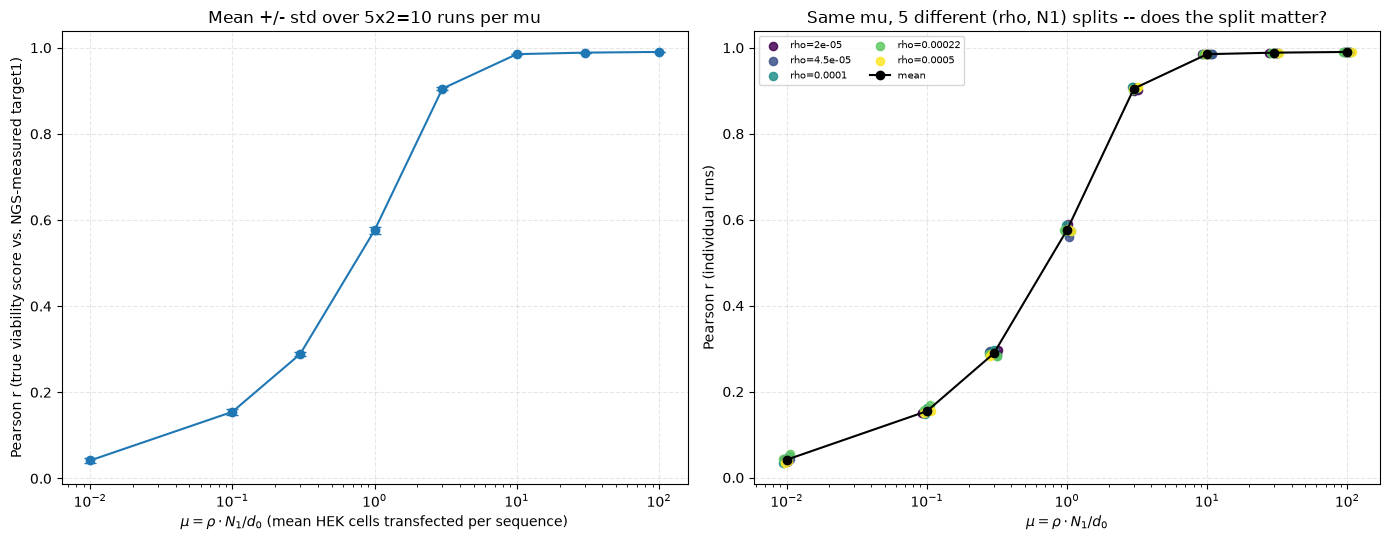

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.errorbar(summary_a1_df["mu"], summary_a1_df["r_mean"], yerr=summary_a1_df["r_std"],
            marker="o", capsize=4, color="tab:blue", linestyle="-")
ax.set_xscale("log")
ax.set_xlabel(r"$\mu = \rho \cdot N_1 / d_0$ (mean HEK cells transfected per sequence)")
ax.set_ylabel("Pearson r (true viability score vs. NGS-measured target1)")
ax.set_title(f"Mean +/- std over {len(RHO_SCALES)}x{N_REPEATS}={len(RHO_SCALES) * N_REPEATS} runs per mu")
ax.grid(True, linestyle="--", alpha=0.3)

ax = axes[1]
rng_jitter = np.random.default_rng(0)
cmap = plt.get_cmap("viridis", len(RHO_SCALES))
for i, rho_k in enumerate(RHO_BASE * RHO_SCALES):
    sub = records_a1_df[np.isclose(records_a1_df["rho"], rho_k)]
    jitter = rng_jitter.uniform(0.92, 1.08, size=len(sub))
    ax.scatter(sub["mu"] * jitter, sub["r"], color=cmap(i), s=35, alpha=0.85, label=f"rho={rho_k:.2g}")
ax.plot(summary_a1_df["mu"], summary_a1_df["r_mean"], color="black", marker="o", lw=1.5, label="mean")
ax.set_xscale("log")
ax.set_xlabel(r"$\mu = \rho \cdot N_1 / d_0$")
ax.set_ylabel("Pearson r (individual runs)")
ax.set_title("Same mu, 5 different (rho, N1) splits -- does the split matter?")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, linestyle="--", alpha=0.3)

fig.tight_layout()
plt.show()


## A.2 Top-`K_TOPK` recovery vs `mu`: GT vs protocol vs MLP


In [12]:
mu_records = []
target1_test_by_mu, preds_mlp_by_mu = {}, {}
target1_eval_by_mu, preds_mlp_eval_by_mu = {}, {}

try:
    for mu in tqdm(MU_GRID, desc="A.2: mu sweep (top-K recovery)"):
        N1_mu = mu * D0_BASE / RHO_BASE
        protocol.N1, protocol.N0, protocol._rho = float(N1_mu), float(make_N0(N1_mu)), float(RHO_BASE)
        protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)

        N1_eval_mu = mu * EVAL_POOL_SIZE / RHO_BASE
        protocol_eval.N1, protocol_eval.N0, protocol_eval._rho = (
            float(N1_eval_mu), float(make_N0(N1_eval_mu)), float(RHO_BASE))
        protocol_eval.lambda0 = jnp.full(protocol_eval.d0, protocol_eval.N0 / protocol_eval.d0)

        _bio_row, ngs_row = protocol.loop_DE()
        lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
        target1_mu = np.log((lambda2p + eps) / (lambda0p + eps))
        target1_train_mu, target1_test_mu = target1_mu[idx_train_base], target1_mu[idx_test_base]

        _bio_row_ev, ngs_row_ev = protocol_eval.loop_DE()
        lambda0p_ev, lambda2p_ev, _lambda3p_ev = (np.asarray(a) for a in ngs_row_ev)
        target1_eval_mu = np.log((lambda2p_ev + eps) / (lambda0p_ev + eps))

        Xtr_mu, ytr_mu, Xva_mu, yva_mu = split_train_val(X_train_full_base, target1_train_mu,
                                                          val_frac=0.15, seed=0)
        model_mu, *_ = train_shallow(Xtr_mu, ytr_mu, Xva_mu, yva_mu, epochs=300, patience=20)
        pred_mu = np.asarray(predict_log_enrichment(model_mu, jnp.asarray(X_test_base)))
        pred_eval_mu = np.asarray(predict_log_enrichment(model_mu, jnp.asarray(X_eval)))

        mu_records.append(dict(
            mu=mu,
            rec_gt_protocol=topk_recovery(viab_score_test_base, target1_test_mu, k=K_TOPK),
            rec_gt_mlp=topk_recovery(viab_score_test_base, pred_mu, k=K_TOPK),
            rec_protocol_mlp=topk_recovery(target1_test_mu, pred_mu, k=K_TOPK),
            rec_gt_protocol_eval=topk_recovery(eval_viab_score, target1_eval_mu, k=K_TOPK),
            rec_gt_mlp_eval=topk_recovery(eval_viab_score, pred_eval_mu, k=K_TOPK),
            rec_protocol_mlp_eval=topk_recovery(target1_eval_mu, pred_eval_mu, k=K_TOPK),
        ))
        target1_test_by_mu[mu], preds_mlp_by_mu[mu] = target1_test_mu, pred_mu
        target1_eval_by_mu[mu], preds_mlp_eval_by_mu[mu] = target1_eval_mu, pred_eval_mu
finally:
    protocol.N1, protocol.N0, protocol._rho = N1_BASE, make_N0(N1_BASE), RHO_BASE
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
    protocol_eval.N1, protocol_eval.N0, protocol_eval._rho = N1_EVAL_BASE, make_N0(N1_EVAL_BASE), RHO_BASE
    protocol_eval.lambda0 = jnp.full(protocol_eval.d0, protocol_eval.N0 / protocol_eval.d0)

mu_sweep_df = pd.DataFrame(mu_records)
mu_sweep_df


A.2: mu sweep (top-K recovery): 100%|██████████| 8/8 [05:00<00:00, 37.53s/it]


,mu,rec_gt_protocol,rec_gt_mlp,rec_protocol_mlp,rec_gt_protocol_eval,rec_gt_mlp_eval,rec_protocol_mlp_eval
0,0.01,0.175,0.270,0.169,0.017,0.057,0.025
1,0.10,0.163,0.324,0.152,0.086,0.085,0.044
2,0.30,0.252,0.420,0.260,0.279,0.180,0.118
3,1.00,0.613,0.634,0.503,0.566,0.295,0.248
4,3.00,0.879,0.818,0.771,0.736,0.537,0.483
5,10.00,0.935,0.892,0.878,0.839,0.724,0.680
6,30.00,0.971,0.913,0.910,0.908,0.736,0.723
7,100.00,0.976,0.900,0.905,0.953,0.737,0.728


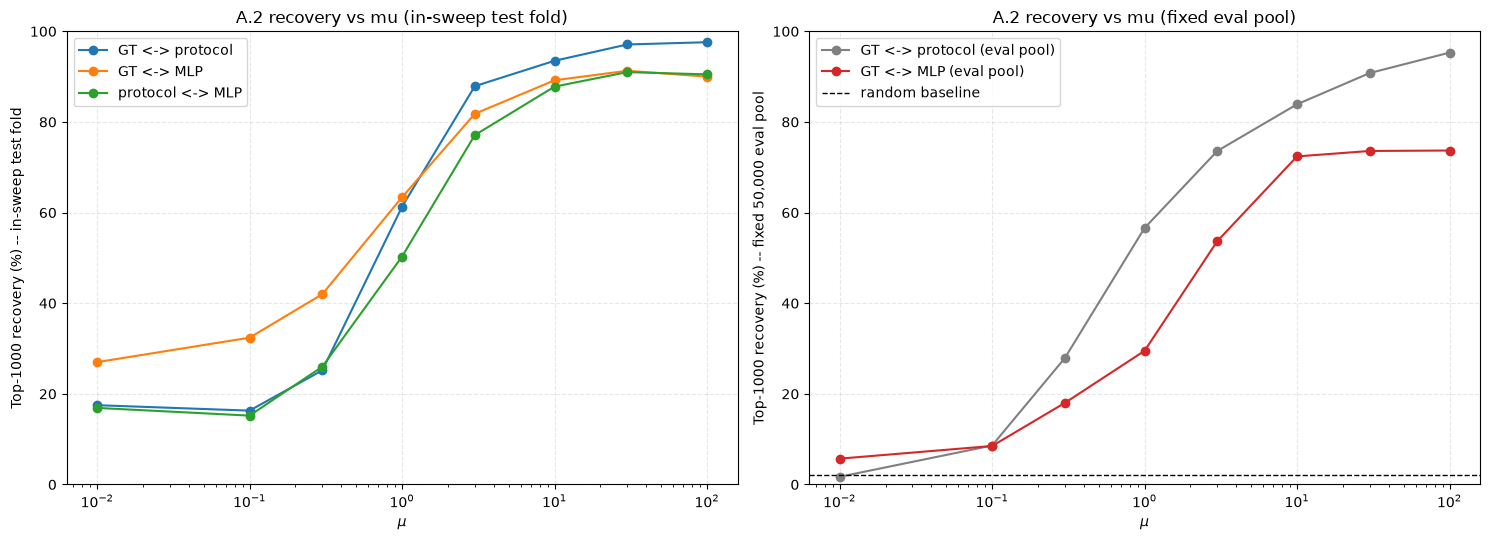

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
ax.plot(mu_sweep_df["mu"], 100 * mu_sweep_df["rec_gt_protocol"], "o-", label="GT <-> protocol")
ax.plot(mu_sweep_df["mu"], 100 * mu_sweep_df["rec_gt_mlp"], "o-", label="GT <-> MLP")
ax.plot(mu_sweep_df["mu"], 100 * mu_sweep_df["rec_protocol_mlp"], "o-", label="protocol <-> MLP")
ax.set_xscale("log"); ax.set_ylim(0, 100)
ax.set_xlabel(r"$\mu$"); ax.set_ylabel(f"Top-{K_TOPK} recovery (%) -- in-sweep test fold")
ax.set_title("A.2 recovery vs mu (in-sweep test fold)")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.3)

ax = axes[1]
ax.plot(mu_sweep_df["mu"], 100 * mu_sweep_df["rec_gt_protocol_eval"], "o-", color="gray", label="GT <-> protocol (eval pool)")
ax.plot(mu_sweep_df["mu"], 100 * mu_sweep_df["rec_gt_mlp_eval"], "o-", color="tab:red", label="GT <-> MLP (eval pool)")
ax.axhline(100 * K_TOPK / EVAL_POOL_SIZE, color="black", lw=1, ls="--", label="random baseline")
ax.set_xscale("log"); ax.set_ylim(0, 100)
ax.set_xlabel(r"$\mu$"); ax.set_ylabel(f"Top-{K_TOPK} recovery (%) -- fixed {EVAL_POOL_SIZE:,} eval pool")
ax.set_title("A.2 recovery vs mu (fixed eval pool)")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


### A.2b Best vs worst `mu`: the three recovery views side by side

Ranked by `rec_gt_mlp` (GT <-> MLP top-K recovery).


best mu  (highest GT<->MLP recovery): 30  (91.3%)
worst mu (lowest GT<->MLP recovery):  0.01  (27.0%)


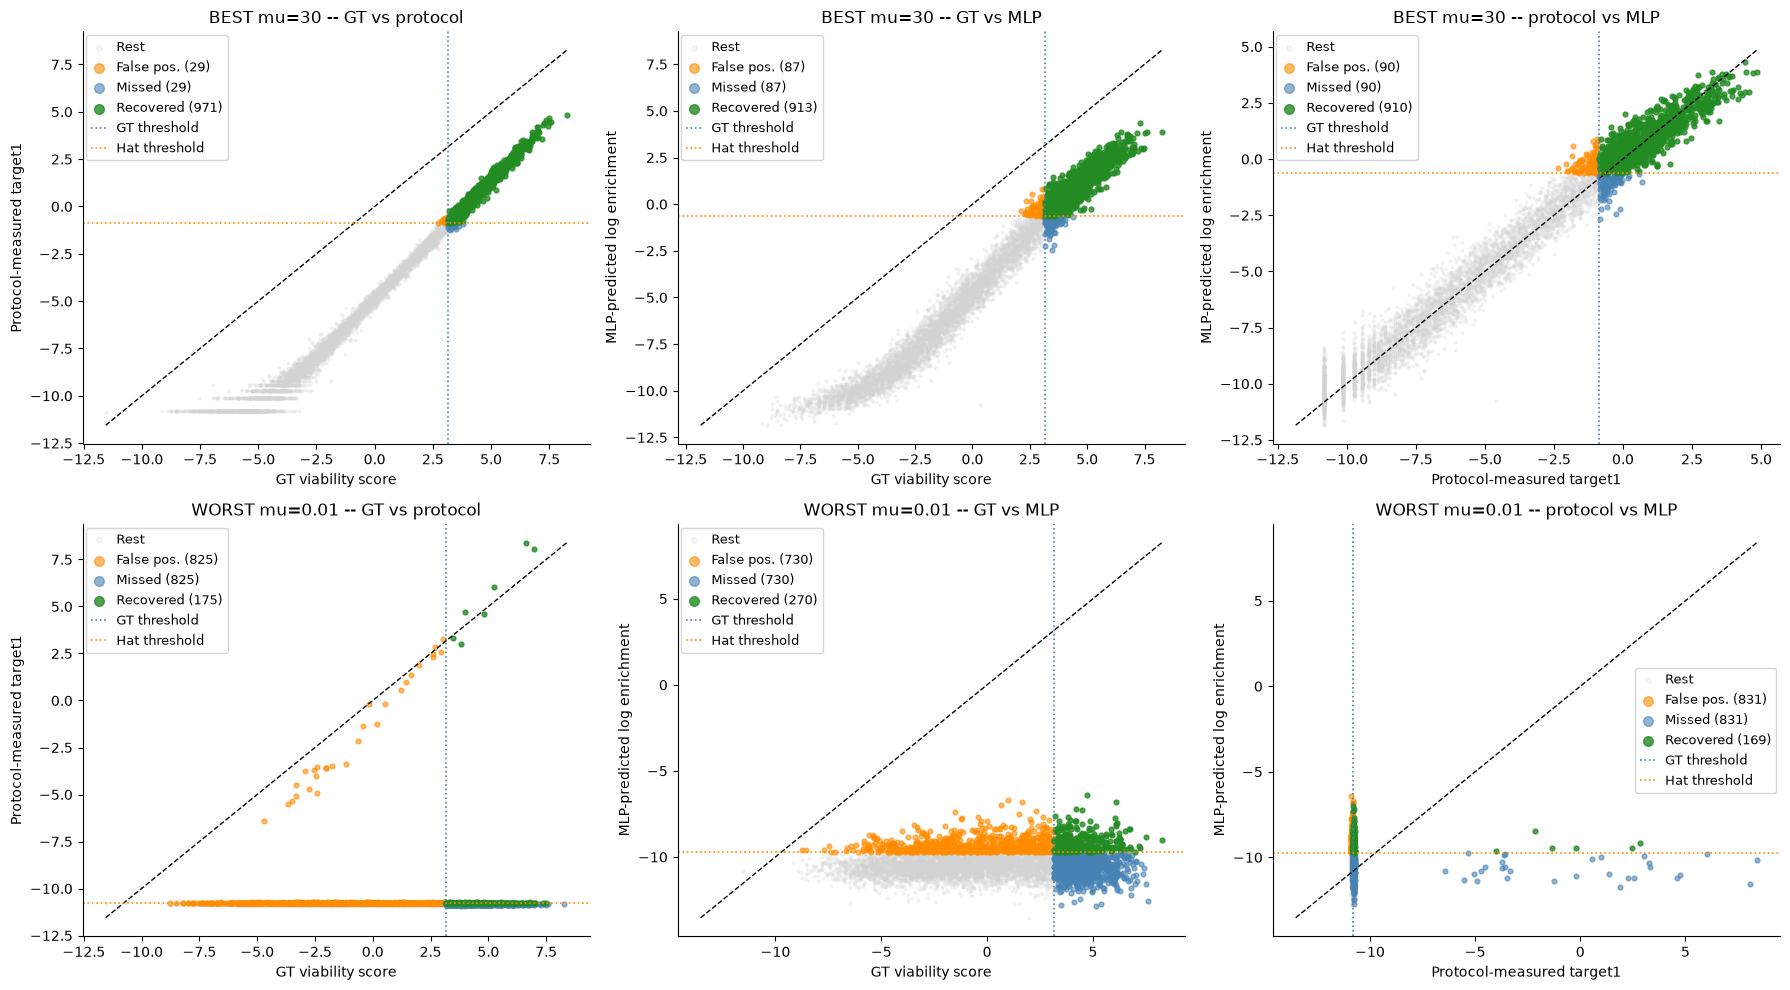

In [14]:
best_mu  = mu_sweep_df.loc[mu_sweep_df["rec_gt_mlp"].idxmax(), "mu"]
worst_mu = mu_sweep_df.loc[mu_sweep_df["rec_gt_mlp"].idxmin(), "mu"]
print(f"best mu  (highest GT<->MLP recovery): {best_mu:g}  ({100 * mu_sweep_df['rec_gt_mlp'].max():.1f}%)")
print(f"worst mu (lowest GT<->MLP recovery):  {worst_mu:g}  ({100 * mu_sweep_df['rec_gt_mlp'].min():.1f}%)")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, (mu_sel, label) in enumerate([(best_mu, "BEST"), (worst_mu, "WORST")]):
    target1_sel, pred_sel = target1_test_by_mu[mu_sel], preds_mlp_by_mu[mu_sel]
    plot_topk_recovery(viab_score_test_base, target1_sel, k_frac=k_frac_test_base,
                        title=f"{label} mu={mu_sel:g} -- GT vs protocol",
                        xlabel="GT viability score", ylabel="Protocol-measured target1", ax=axes[row, 0])
    plot_topk_recovery(viab_score_test_base, pred_sel, k_frac=k_frac_test_base,
                        title=f"{label} mu={mu_sel:g} -- GT vs MLP",
                        xlabel="GT viability score", ylabel="MLP-predicted log enrichment", ax=axes[row, 1])
    plot_topk_recovery(target1_sel, pred_sel, k_frac=k_frac_test_base,
                        title=f"{label} mu={mu_sel:g} -- protocol vs MLP",
                        xlabel="Protocol-measured target1", ylabel="MLP-predicted log enrichment", ax=axes[row, 2])
fig.tight_layout()
plt.show()


## A.3 Same sweep, `noise_viab=noise_sel=0` -- how much of the gap is that noise term?


In [15]:
orig_nv, orig_ns = protocol.noise_viab, protocol.noise_sel
orig_nv_e, orig_ns_e = protocol_eval.noise_viab, protocol_eval.noise_sel

mu_nonoise_records = []
try:
    protocol.noise_viab = protocol.noise_sel = 0.0
    protocol_eval.noise_viab = protocol_eval.noise_sel = 0.0
    for mu in tqdm(MU_GRID, desc="A.3: mu sweep, no noise"):
        N1_mu = mu * D0_BASE / RHO_BASE
        protocol.N1, protocol.N0, protocol._rho = float(N1_mu), float(make_N0(N1_mu)), float(RHO_BASE)
        protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)

        N1_eval_mu = mu * EVAL_POOL_SIZE / RHO_BASE
        protocol_eval.N1, protocol_eval.N0, protocol_eval._rho = (
            float(N1_eval_mu), float(make_N0(N1_eval_mu)), float(RHO_BASE))
        protocol_eval.lambda0 = jnp.full(protocol_eval.d0, protocol_eval.N0 / protocol_eval.d0)

        _bio_row, ngs_row = protocol.loop_DE()
        lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
        target1_mu = np.log((lambda2p + eps) / (lambda0p + eps))
        target1_train_mu, target1_test_mu = target1_mu[idx_train_base], target1_mu[idx_test_base]

        _bio_row_ev, ngs_row_ev = protocol_eval.loop_DE()
        lambda0p_ev, lambda2p_ev, _lambda3p_ev = (np.asarray(a) for a in ngs_row_ev)
        target1_eval_mu = np.log((lambda2p_ev + eps) / (lambda0p_ev + eps))

        Xtr_mu, ytr_mu, Xva_mu, yva_mu = split_train_val(X_train_full_base, target1_train_mu,
                                                          val_frac=0.15, seed=0)
        model_mu, *_ = train_shallow(Xtr_mu, ytr_mu, Xva_mu, yva_mu, epochs=300, patience=20)
        pred_mu = np.asarray(predict_log_enrichment(model_mu, jnp.asarray(X_test_base)))
        pred_eval_mu = np.asarray(predict_log_enrichment(model_mu, jnp.asarray(X_eval)))

        mu_nonoise_records.append(dict(
            mu=mu,
            rec_gt_protocol=topk_recovery(viab_score_test_base, target1_test_mu, k=K_TOPK),
            rec_gt_mlp=topk_recovery(viab_score_test_base, pred_mu, k=K_TOPK),
            rec_protocol_mlp=topk_recovery(target1_test_mu, pred_mu, k=K_TOPK),
            rec_gt_protocol_eval=topk_recovery(eval_viab_score, target1_eval_mu, k=K_TOPK),
            rec_gt_mlp_eval=topk_recovery(eval_viab_score, pred_eval_mu, k=K_TOPK),
            rec_protocol_mlp_eval=topk_recovery(target1_eval_mu, pred_eval_mu, k=K_TOPK),
        ))
finally:
    protocol.N1, protocol.N0, protocol._rho = N1_BASE, make_N0(N1_BASE), RHO_BASE
    protocol.noise_viab, protocol.noise_sel = orig_nv, orig_ns
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
    protocol_eval.N1, protocol_eval.N0, protocol_eval._rho = N1_EVAL_BASE, make_N0(N1_EVAL_BASE), RHO_BASE
    protocol_eval.noise_viab, protocol_eval.noise_sel = orig_nv_e, orig_ns_e
    protocol_eval.lambda0 = jnp.full(protocol_eval.d0, protocol_eval.N0 / protocol_eval.d0)

mu_nonoise_df = pd.DataFrame(mu_nonoise_records)
mu_nonoise_df


A.3: mu sweep, no noise: 100%|██████████| 8/8 [05:11<00:00, 38.96s/it]


,mu,rec_gt_protocol,rec_gt_mlp,rec_protocol_mlp,rec_gt_protocol_eval,rec_gt_mlp_eval,rec_protocol_mlp_eval
0,0.01,0.161,0.224,0.176,0.024,0.058,0.014
1,0.10,0.174,0.340,0.165,0.096,0.113,0.049
2,0.30,0.260,0.447,0.250,0.255,0.184,0.115
3,1.00,0.626,0.630,0.519,0.613,0.319,0.269
4,3.00,0.891,0.821,0.794,0.752,0.588,0.534
5,10.00,0.951,0.901,0.884,0.861,0.738,0.696
6,30.00,0.977,0.901,0.897,0.917,0.720,0.718
7,100.00,0.986,0.909,0.908,0.964,0.746,0.742


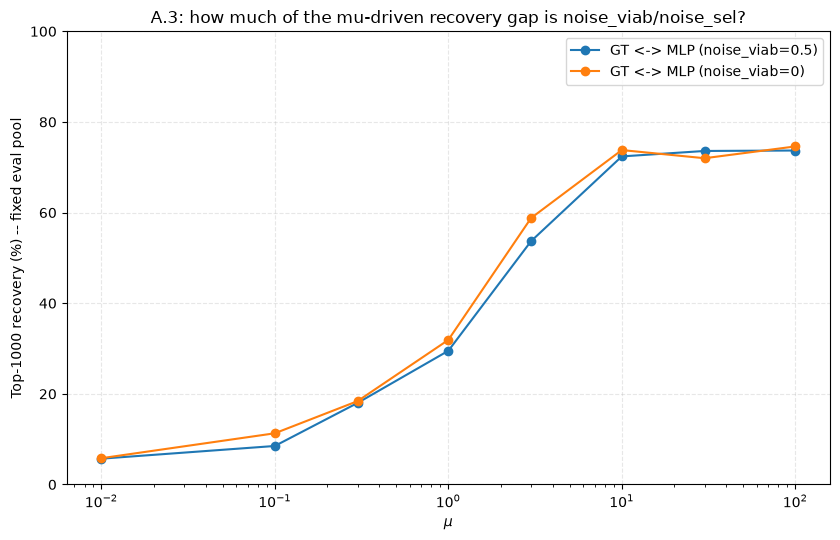

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(mu_sweep_df["mu"], 100 * mu_sweep_df["rec_gt_mlp_eval"], "o-", label="GT <-> MLP (noise_viab=0.5)")
ax.plot(mu_nonoise_df["mu"], 100 * mu_nonoise_df["rec_gt_mlp_eval"], "o-", label="GT <-> MLP (noise_viab=0)")
ax.set_xscale("log"); ax.set_ylim(0, 100)
ax.set_xlabel(r"$\mu$"); ax.set_ylabel(f"Top-{K_TOPK} recovery (%) -- fixed eval pool")
ax.set_title("A.3: how much of the mu-driven recovery gap is noise_viab/noise_sel?")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


## Shared harness for sections B-D

Sections B (`T_viab`), C (`noise_viab`), and D (`D`) all follow the exact same recipe: mutate ONE
attribute of the shared `protocol`/`protocol_eval` pair in place, reset `lambda0`, run one
`loop_DE()` round each, train one fresh `ShallowProfileMLP` on the shared train fold, then measure
Pearson `r` and top-`K_TOPK` recovery (GT/protocol/MLP) on both the shared in-sweep test fold and
the fixed eval pool. Factored into one function here instead of copy-pasted three times.


In [17]:
def run_1d_sweep(param_name, grid, set_value, desc):
    """set_value(proto, val) mutates proto's swept attribute in place; called identically on
    `protocol` and `protocol_eval` at every grid point. Returns a DataFrame with r_*/rec_*
    columns, the same schema used by every single-parameter sweep in this notebook."""
    records = []
    for val in tqdm(grid, desc=desc):
        set_value(protocol, val)
        protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
        set_value(protocol_eval, val)
        protocol_eval.lambda0 = jnp.full(protocol_eval.d0, protocol_eval.N0 / protocol_eval.d0)

        _bio_row, ngs_row = protocol.loop_DE()
        lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
        target1 = np.log((lambda2p + eps) / (lambda0p + eps))
        _bio_row_eval, ngs_row_eval = protocol_eval.loop_DE()
        lambda0p_eval, lambda2p_eval, _lambda3p_eval = (np.asarray(a) for a in ngs_row_eval)
        target1_eval = np.log((lambda2p_eval + eps) / (lambda0p_eval + eps))
        target1_train, target1_test = target1[idx_train_base], target1[idx_test_base]

        Xtr, ytr, Xva, yva = split_train_val(X_train_full_base, target1_train, val_frac=0.15, seed=0)
        model, *_ = train_shallow(Xtr, ytr, Xva, yva, epochs=300, patience=20)
        pred_test = np.asarray(predict_log_enrichment(model, jnp.asarray(X_test_base)))
        pred_eval = np.asarray(predict_log_enrichment(model, jnp.asarray(X_eval)))

        records.append({
            param_name: val,
            "r_gt_protocol": pearson(viab_score_test_base, target1_test),
            "r_gt_mlp": pearson(viab_score_test_base, pred_test),
            "r_protocol_mlp": pearson(target1_test, pred_test),
            "rec_gt_protocol": topk_recovery(viab_score_test_base, target1_test, k=K_TOPK),
            "rec_gt_mlp": topk_recovery(viab_score_test_base, pred_test, k=K_TOPK),
            "rec_protocol_mlp": topk_recovery(target1_test, pred_test, k=K_TOPK),
            "rec_gt_mlp_eval": topk_recovery(eval_viab_score, pred_eval, k=K_TOPK),
            "r_gt_protocol_eval": pearson(eval_viab_score, target1_eval),
            "rec_gt_protocol_eval": topk_recovery(eval_viab_score, target1_eval, k=K_TOPK),
            "r_protocol_mlp_eval": pearson(target1_eval, pred_eval),
            "rec_protocol_mlp_eval": topk_recovery(target1_eval, pred_eval, k=K_TOPK),
        })
    return pd.DataFrame(records)


def plot_1d_sweep(df, param_name, xlabel, title_prefix, logx=True):
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))

    ax = axes[0]
    ax.plot(df[param_name], df["r_gt_protocol"], "o-", label="GT <-> protocol")
    ax.plot(df[param_name], df["r_gt_mlp"], "o-", label="GT <-> MLP")
    ax.plot(df[param_name], df["r_protocol_mlp"], "o-", label="protocol <-> MLP")
    if logx: ax.set_xscale("log")
    ax.set_ylim(0, 1); ax.set_xlabel(xlabel); ax.set_ylabel("Pearson r")
    ax.set_title(f"{title_prefix}: Pearson r"); ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.3)

    ax = axes[1]
    ax.plot(df[param_name], 100 * df["rec_gt_protocol"], "o-", label="GT <-> protocol")
    ax.plot(df[param_name], 100 * df["rec_gt_mlp"], "o-", label="GT <-> MLP")
    ax.plot(df[param_name], 100 * df["rec_protocol_mlp"], "o-", label="protocol <-> MLP")
    if logx: ax.set_xscale("log")
    ax.set_ylim(0, 100); ax.set_xlabel(xlabel); ax.set_ylabel(f"Top-{K_TOPK} recovery (%)")
    ax.set_title(f"{title_prefix}: recovery (in-sweep test fold)"); ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.3)

    ax = axes[2]
    ax.plot(df[param_name], 100 * df["rec_gt_protocol_eval"], "o-", color="gray", label="GT <-> protocol (eval pool)")
    ax.plot(df[param_name], 100 * df["rec_gt_mlp_eval"], "o-", color="tab:red", label="GT <-> MLP (eval pool)")
    ax.axhline(100 * K_TOPK / EVAL_POOL_SIZE, color="black", lw=1, ls="--", label="random baseline")
    if logx: ax.set_xscale("log")
    ax.set_ylim(0, 100); ax.set_xlabel(xlabel); ax.set_ylabel(f"Top-{K_TOPK} recovery (%)")
    ax.set_title(f"{title_prefix}: recovery (fixed {EVAL_POOL_SIZE:,} eval pool)"); ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.3)

    fig.tight_layout()
    plt.show()


# Section B -- Influence of `T_viab` (viability temperature)

`rate = alpha * E * exp(score / T_viab)` in `produce_capsids` -- small `T_viab` means a handful of
top-scoring sequences dominate production (sharp selection); large `T_viab` washes the score out
of the rate entirely (`exp(score/T_viab) -> 1` for everyone). Expect a UNIMODAL curve, not
monotonic, and the Pearson-`r` peak need not land at the same `T_viab` as the top-K-recovery peak
(global-ranking fidelity vs. extreme-tail fidelity are different questions).


In [18]:
original_T_viab = protocol._T_viab
try:
    T_viab_sweep_df = run_1d_sweep("T_viab", T_VIAB_GRID,
        lambda p, v: setattr(p, "_T_viab", float(v)), "B: T_viab sweep")
finally:
    protocol._T_viab = original_T_viab
    protocol_eval._T_viab = original_T_viab

T_viab_sweep_df


B: T_viab sweep: 100%|██████████| 15/15 [10:17<00:00, 41.14s/it]


,T_viab,r_gt_protocol,r_gt_mlp,r_protocol_mlp,rec_gt_protocol,rec_gt_mlp,rec_protocol_mlp,rec_gt_mlp_eval,r_gt_protocol_eval,rec_gt_protocol_eval,r_protocol_mlp_eval,rec_protocol_mlp_eval
0,0.1,0.859553,0.888985,0.940671,0.486,0.609,0.463,0.003,0.855317,0.058,0.936158,0.054
1,0.2,0.875630,0.889634,0.966243,0.630,0.822,0.634,0.008,0.870976,0.071,0.963113,0.090
2,0.3,0.890202,0.896009,0.978403,0.979,0.898,0.892,0.127,0.881384,0.114,0.974976,0.125
3,0.4,0.904589,0.904595,0.979069,0.967,0.902,0.899,0.549,0.892030,0.212,0.977221,0.237
4,0.5,0.923467,0.920063,0.980367,0.956,0.909,0.905,0.710,0.908266,0.580,0.977219,0.520
5,0.6,0.947417,0.942421,0.980423,0.956,0.897,0.889,0.730,0.932505,0.878,0.977929,0.704
6,0.7,0.970712,0.962525,0.979112,0.947,0.894,0.881,0.721,0.958521,0.864,0.976823,0.689
7,0.8,0.984430,0.977344,0.979550,0.940,0.892,0.884,0.722,0.977186,0.841,0.977926,0.686
8,0.9,0.990550,0.983049,0.978564,0.933,0.897,0.879,0.739,0.986063,0.834,0.977798,0.690
9,1.0,0.990888,0.983983,0.976380,0.932,0.895,0.877,0.712,0.989229,0.820,0.976791,0.659


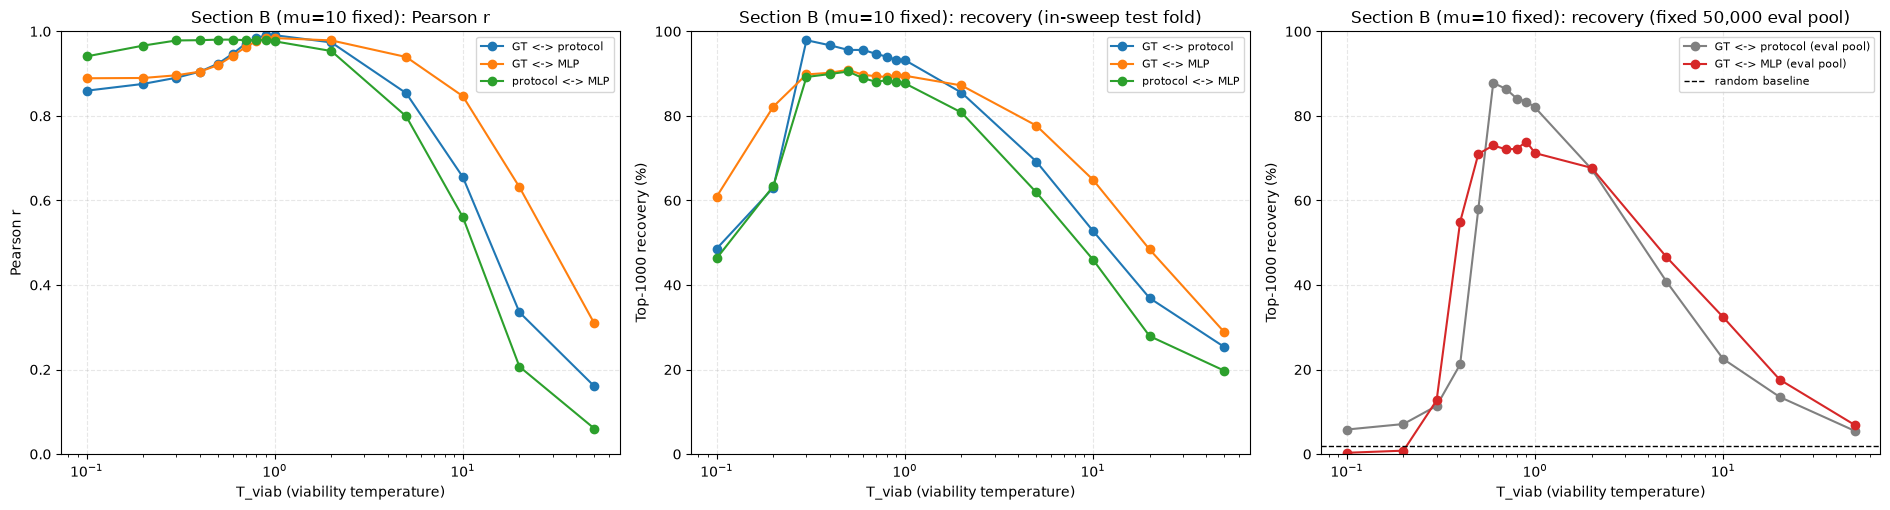

In [19]:
plot_1d_sweep(T_viab_sweep_df, "T_viab", "T_viab (viability temperature)",
              f"Section B (mu={MU_BASE} fixed)")


# Section C -- Influence of `noise_viab` (per-cell expression noise)

`E_{s,j} = exp(noise_viab * Z_{s,j})` in `produce_capsids`. **Denoising signature**: if
`GT <-> MLP` stays ABOVE `GT <-> protocol` as `noise_viab` grows, the MLP is genuinely denoising
(recovering the true score better than the single noisy measurement it was trained on) by
averaging over the redundancy in its training fold. `protocol <-> MLP` is expected to be the
LOWEST of the three at every point: the MLP prediction never sees the test fold's specific noise
draw, so independent noise on one side of that correlation can only hurt it.


In [20]:
original_noise_viab = protocol.noise_viab
try:
    noise_viab_sweep_df = run_1d_sweep("noise_viab", NOISE_GRID,
        lambda p, v: setattr(p, "noise_viab", float(v)), "C: noise_viab sweep")
finally:
    protocol.noise_viab = original_noise_viab
    protocol_eval.noise_viab = original_noise_viab

noise_viab_sweep_df


C: noise_viab sweep: 100%|██████████| 8/8 [05:53<00:00, 44.23s/it]


,noise_viab,r_gt_protocol,r_gt_mlp,r_protocol_mlp,rec_gt_protocol,rec_gt_mlp,rec_protocol_mlp,rec_gt_mlp_eval,r_gt_protocol_eval,rec_gt_protocol_eval,r_protocol_mlp_eval,rec_protocol_mlp_eval
0,0.00,0.985845,0.978329,0.980982,0.947,0.894,0.885,0.731,0.978373,0.851,0.979566,0.695
1,0.10,0.985905,0.976386,0.979482,0.949,0.893,0.885,0.712,0.978441,0.866,0.977878,0.693
2,0.25,0.985455,0.978526,0.980796,0.940,0.897,0.875,0.722,0.978194,0.864,0.978772,0.691
3,0.50,0.984754,0.977839,0.979947,0.943,0.898,0.873,0.729,0.977311,0.846,0.978560,0.692
4,1.00,0.980045,0.975401,0.973250,0.916,0.893,0.864,0.702,0.972866,0.797,0.971733,0.645
5,2.00,0.955165,0.966625,0.942191,0.840,0.867,0.786,0.638,0.948021,0.638,0.940445,0.500
6,4.00,0.868168,0.943190,0.828782,0.687,0.794,0.626,0.485,0.861671,0.206,0.821158,0.172
7,8.00,0.608762,0.802748,0.503419,0.338,0.596,0.310,0.152,0.611130,0.047,0.509111,0.032


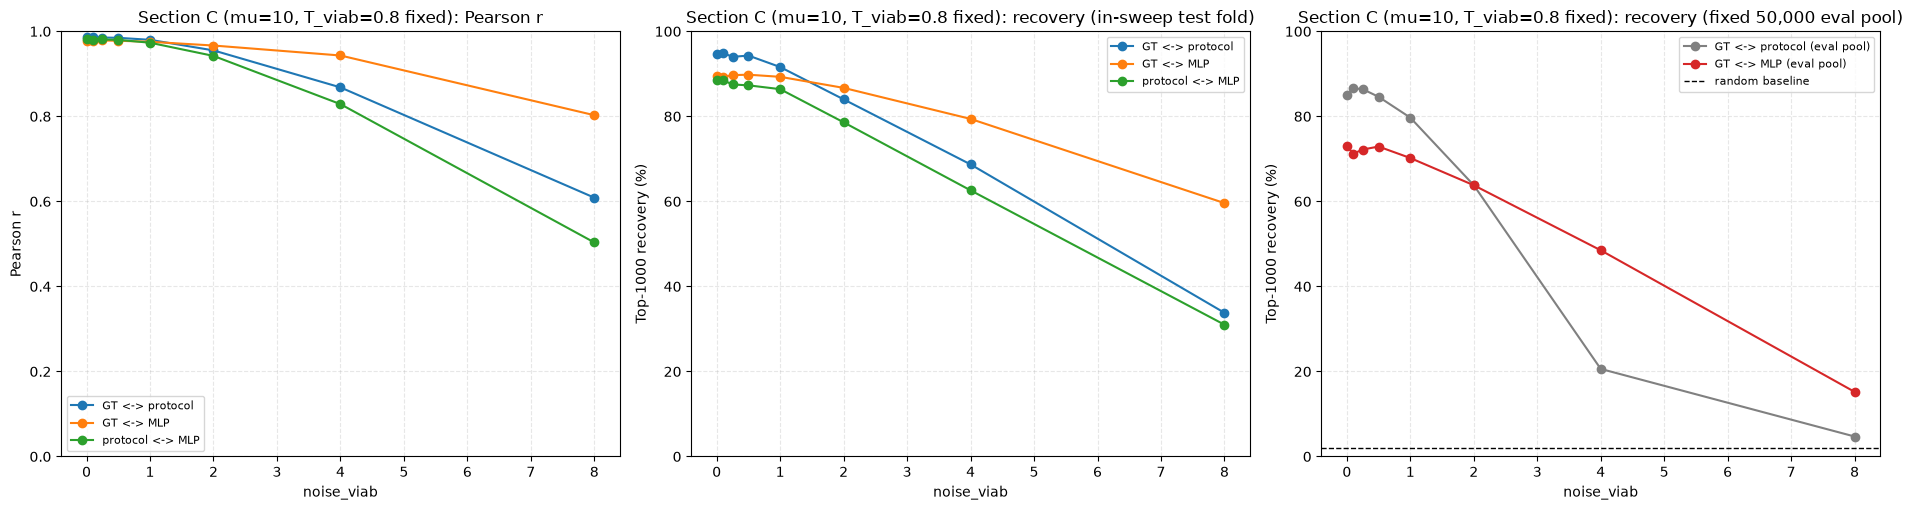

In [21]:
plot_1d_sweep(noise_viab_sweep_df, "noise_viab", "noise_viab",
              f"Section C (mu={MU_BASE}, T_viab={T_VIAB_BASE} fixed)", logx=False)


# Section D -- Influence of `D` (NGS sequencing depth per checkpoint)

With `multinomialNGS=True`, reads are drawn as `Multinomial(D, proportions)` -- reads sum to
exactly `D`. Both curves should be MONOTONIC increasing in `D` (unlike `T_viab`'s unimodal shape:
there is no "too much sequencing" failure mode), with diminishing returns once `D/d0` is already
large relative to the other noise sources at play.


In [22]:
original_D = protocol.D
try:
    D_sweep_df = run_1d_sweep("D", D_GRID,
        lambda p, v: setattr(p, "D", float(v)), "D: D sweep")
finally:
    protocol.D = original_D
    protocol_eval.D = original_D

D_sweep_df


D: D sweep: 100%|██████████| 9/9 [09:08<00:00, 60.98s/it]


,D,r_gt_protocol,r_gt_mlp,r_protocol_mlp,rec_gt_protocol,rec_gt_mlp,rec_protocol_mlp,rec_gt_mlp_eval,r_gt_protocol_eval,rec_gt_protocol_eval,r_protocol_mlp_eval,rec_protocol_mlp_eval
0,1.000000e+06,0.822212,0.838783,0.949765,0.925,0.889,0.865,0.743,0.768361,0.810,0.926209,0.695
1,3.000000e+06,0.867844,0.880727,0.962367,0.931,0.889,0.871,0.725,0.828711,0.842,0.948344,0.691
2,1.000000e+07,0.908861,0.910919,0.970500,0.934,0.888,0.877,0.728,0.878067,0.836,0.961200,0.700
3,3.000000e+07,0.936543,0.937304,0.974519,0.938,0.906,0.890,0.730,0.913037,0.845,0.967537,0.680
4,1.000000e+08,0.961133,0.957064,0.977965,0.944,0.892,0.888,0.725,0.943433,0.844,0.973133,0.685
5,3.000000e+08,0.974702,0.968775,0.978487,0.938,0.904,0.889,0.724,0.962871,0.843,0.975911,0.684
6,1.000000e+09,0.984761,0.977785,0.979863,0.936,0.894,0.892,0.721,0.977289,0.850,0.978214,0.670
7,3.000000e+09,0.990057,0.983097,0.980576,0.938,0.903,0.886,0.727,0.985462,0.856,0.980124,0.688
8,1.000000e+10,0.992810,0.984024,0.980140,0.938,0.888,0.878,0.717,0.990201,0.860,0.980190,0.684


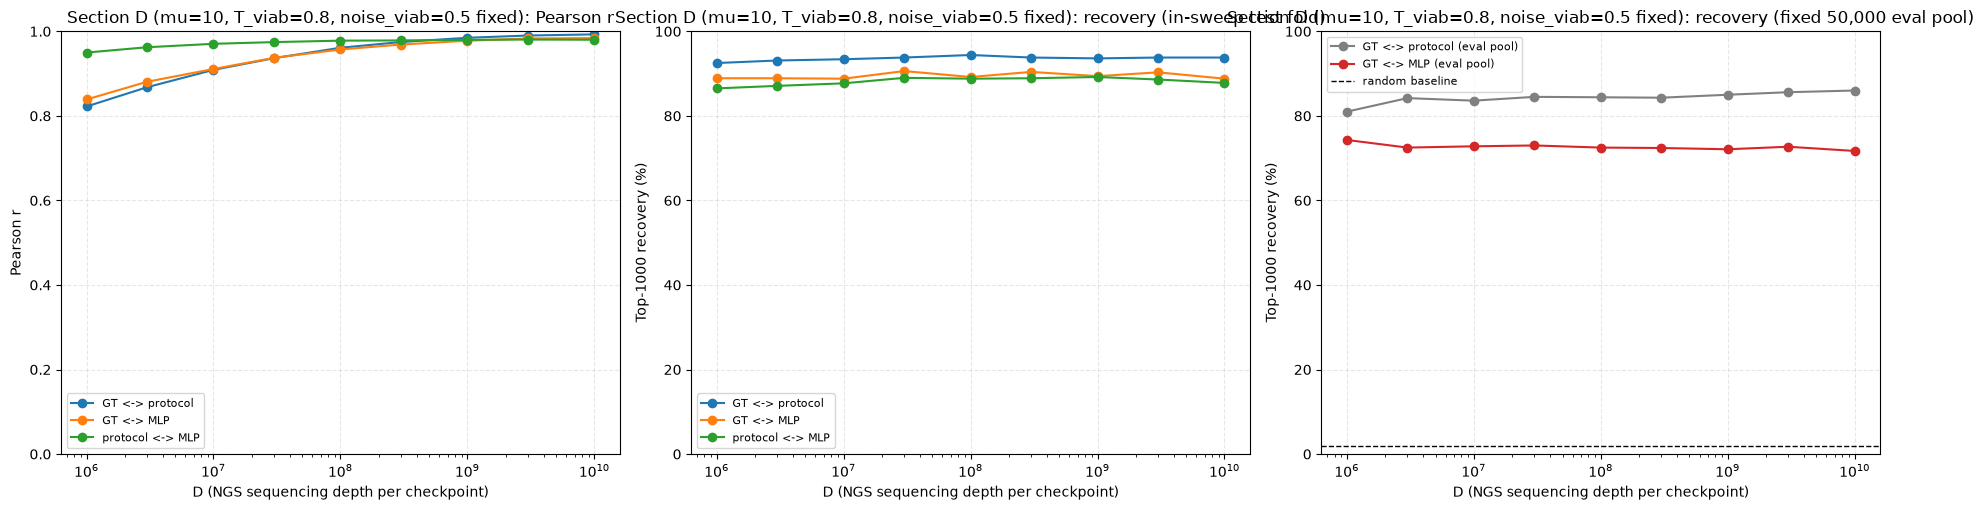

In [23]:
plot_1d_sweep(D_sweep_df, "D", "D (NGS sequencing depth per checkpoint)",
              f"Section D (mu={MU_BASE}, T_viab={T_VIAB_BASE}, noise_viab={NOISE_VIAB_BASE} fixed)")


# Section E -- `noise_viab` x `d0` (2D): does more training data change the denoising curve?

Sections F onward vary `d0`; from here on each grid point gets a FRESH pool + fresh `ProtocolV3`
(`N1 = mu*d0/rho`, `N0=150*N1`, `mu=MU_BASE` fixed regardless of `d0`) -- `lambda0`/`lambda0p`/.../
`lambda4` are allocated at `(d0,)` in `__init__`, so `d0` can't be swept by mutating one reused
object the way sections A-D did.

OUTER loop over `d0` (`DIVERSITY_GRID`, fresh pool+`ProtocolV3` each time, `D=D_BASE` fixed),
INNER loop over `noise_viab` (`NOISE_GRID`, mutating the SAME per-`d0` `protocol` object in place).
Top-`K_TOPK` recovery is measured ONLY on the fixed eval pool (`rec_gt_mlp_eval`) -- the in-sweep
test fold's size scales with `d0` here, which would make recovery not comparable across the `d0`
axis this section is about (same reasoning sections F/G apply to their own sweep). Pearson `r`
still uses the in-sweep test fold since it doesn't have that degeneracy. `batch_size` is adaptive
(`max(256, n_train // 50)`) since `d0` varies 40x across the grid.


In [24]:
records_e = []
base_key_e = jax.random.key(1)

for d0_val in tqdm(DIVERSITY_GRID, desc="E: d0 (outer)", position=0):
    pool_key_e  = jax.random.fold_in(base_key_e, d0_val)
    sequences_e = jax.random.randint(pool_key_e, shape=(d0_val, NUM_POSITIONS),
                                      minval=0, maxval=NUM_AMINO_ACIDS)
    N1_e = MU_BASE * d0_val / RHO_BASE

    protocol_e = ProtocolV3(multinomialNGS=True, N0=make_N0(N1_e), N1=N1_e,
            dilution_factor=10, sequences=sequences_e, D=D_BASE,
            F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
            noise_viab=NOISE_VIAB_BASE, noise_sel=0.5, T_sel=1, T_viab=T_VIAB_BASE,
            )
    protocol_e._rho = float(RHO_BASE)
    viab_score_e = np.array(protocol_e.compute_score(F_viab, J_viab))

    X_all_e = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(sequences_e)].reshape(d0_val, -1)
    idx_train_e, idx_test_e = train_test_split(np.arange(d0_val), test_size=0.3, random_state=0)
    X_train_full_e = X_all_e[idx_train_e]
    batch_size_e = max(256, len(idx_train_e) // 50)

    for nv in tqdm(NOISE_GRID, desc=f"E: noise_viab (d0={d0_val:,})", leave=False, position=1):
        protocol_e.noise_viab = float(nv)
        protocol_e.lambda0 = jnp.full(protocol_e.d0, protocol_e.N0 / protocol_e.d0)

        _bio_row_e, ngs_row_e = protocol_e.loop_DE()
        lambda0p_e, lambda2p_e, _lambda3p_e = (np.asarray(a) for a in ngs_row_e)
        target1_e = np.log((lambda2p_e + eps) / (lambda0p_e + eps))
        target1_train_e = target1_e[idx_train_e]

        Xtr_e, ytr_e, Xva_e, yva_e = split_train_val(X_train_full_e, target1_train_e, val_frac=0.15, seed=0)
        model_e, *_ = train_shallow(Xtr_e, ytr_e, Xva_e, yva_e, epochs=300, patience=20, batch_size=batch_size_e)
        pred_test_e = np.asarray(predict_log_enrichment(model_e, jnp.asarray(X_all_e[idx_test_e])))
        pred_eval_e = np.asarray(predict_log_enrichment(model_e, jnp.asarray(X_eval)))

        records_e.append(dict(
            d0=d0_val, noise_viab=nv,
            r_gt_protocol=pearson(viab_score_e[idx_test_e], target1_e[idx_test_e]),
            r_gt_mlp=pearson(viab_score_e[idx_test_e], pred_test_e),
            rec_gt_mlp_eval=topk_recovery(eval_viab_score, pred_eval_e, k=K_TOPK),
        ))

noise_d0_grid_df = pd.DataFrame(records_e)
noise_d0_grid_df


E: d0 (outer):   0%|          | 0/6 [00:00<?, ?it/s]
















































E: d0 (outer):  17%|█▋        | 1/6 [01:50<09:10, 110.00s/it]
















































E: d0 (outer):  33%|███▎      | 2/6 [05:12<10:58, 164.59s/it]



















































E: d0 (outer):  50%|█████     | 3/6 [08:18<08:43, 174.40s/it]
















































E: d0 (outer):  67%|██████▋   | 4/6 [12:29<06:48, 204.33s/it]

























































E: d0 (outer):  83%|████████▎ | 5/6 [18:55<04:29, 270.00s/it]



















































E: d0 (outer): 100%|██████████| 6/6 [29:09<00:00, 291.55s/it]


,d0,noise_viab,r_gt_protocol,r_gt_mlp,rec_gt_mlp_eval
0,5000,0.00,0.992650,0.967495,0.602
1,5000,0.10,0.992484,0.966809,0.592
2,5000,0.25,0.991821,0.966379,0.600
3,5000,0.50,0.991747,0.966863,0.588
4,5000,1.00,0.987347,0.965900,0.577
5,5000,2.00,0.964098,0.959454,0.562
6,5000,4.00,0.874176,0.922094,0.425
7,5000,8.00,0.597731,0.735860,0.112
8,10000,0.00,0.988797,0.973173,0.655
9,10000,0.10,0.988383,0.973953,0.671


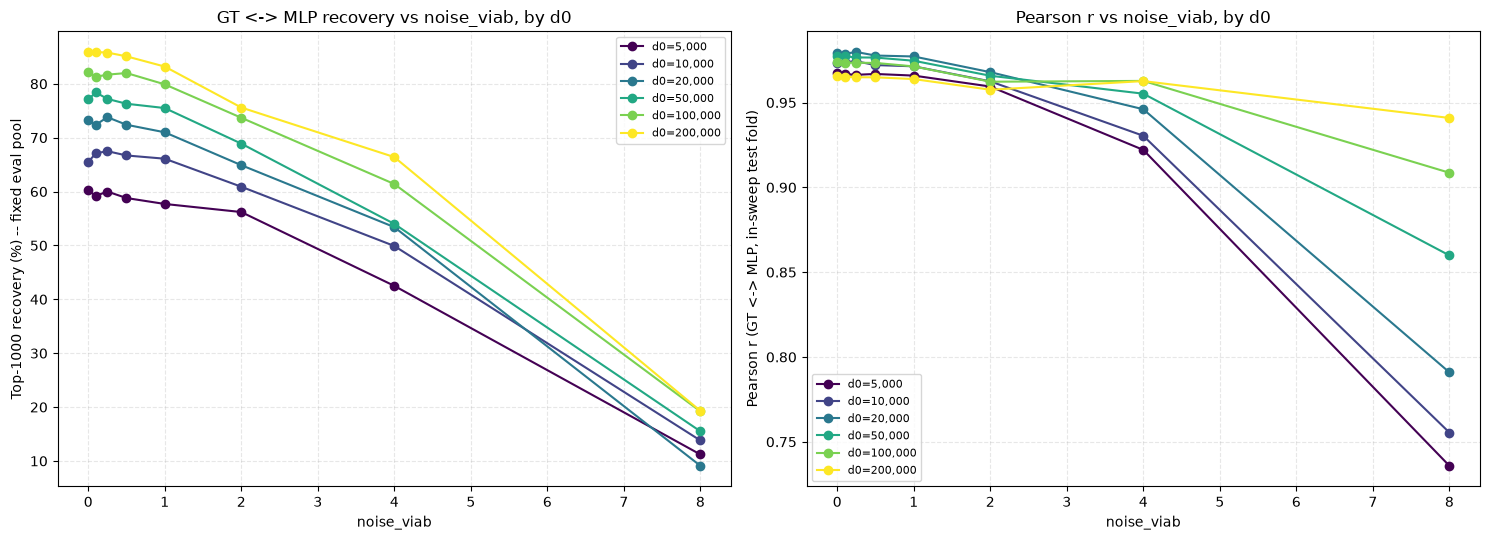

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
cmap = plt.get_cmap("viridis", len(DIVERSITY_GRID))

ax = axes[0]
for i, d0_val in enumerate(DIVERSITY_GRID):
    sub = noise_d0_grid_df[noise_d0_grid_df["d0"] == d0_val].sort_values("noise_viab")
    ax.plot(sub["noise_viab"], 100 * sub["rec_gt_mlp_eval"], "o-", color=cmap(i), label=f"d0={d0_val:,}")
ax.set_xlabel("noise_viab"); ax.set_ylabel(f"Top-{K_TOPK} recovery (%) -- fixed eval pool")
ax.set_title("GT <-> MLP recovery vs noise_viab, by d0"); ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.3)

ax = axes[1]
for i, d0_val in enumerate(DIVERSITY_GRID):
    sub = noise_d0_grid_df[noise_d0_grid_df["d0"] == d0_val].sort_values("noise_viab")
    ax.plot(sub["noise_viab"], sub["r_gt_mlp"], "o-", color=cmap(i), label=f"d0={d0_val:,}")
ax.set_xlabel("noise_viab"); ax.set_ylabel("Pearson r (GT <-> MLP, in-sweep test fold)")
ax.set_title("Pearson r vs noise_viab, by d0"); ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.3)

fig.tight_layout()
plt.show()


# Section F -- Influence of library diversity `d0`, `D` FIXED (not compensated)

`d0` (distinct sequences in the library) is now the swept variable, `5,000` to `200,000`
(`DIVERSITY_GRID`, capped by the `N0=150*N1` constraint at `mu=MU_BASE`, section 3). `mu` is kept
fixed via `N1 = mu*d0/rho` at every point (same compensation trick as section A), but `D` is held
FIXED at `D_FIXED_DIVERSITY=1e8` regardless of `d0` -- a TOTAL sequencing budget shared across the
whole pool, NOT compensated. Reads-per-sequence (`D/d0`) therefore shrinks as the library gets
more diverse: this isolates "does spreading a fixed NGS budget over a more diverse library
degrade signal fidelity", independent of the transfection-multiplicity effect already covered in
section A.

A SEPARATE `protocol_eval` (this section's own, at `D=D_FIXED_DIVERSITY`) gives a genuine
`GT<->protocol` number on the fixed eval pool -- simulated ONCE since nothing here depends on
`d0_val`.


In [26]:
N1_eval_f = MU_BASE * EVAL_POOL_SIZE / RHO_BASE
protocol_eval_f = ProtocolV3(multinomialNGS=True, N0=make_N0(N1_eval_f), N1=N1_eval_f,
        dilution_factor=10, sequences=eval_sequences, D=D_FIXED_DIVERSITY,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=NOISE_VIAB_BASE, noise_sel=0.5, T_sel=1, T_viab=T_VIAB_BASE,
        )
protocol_eval_f._rho = float(RHO_BASE)

_bio_row_ef, ngs_row_ef = protocol_eval_f.loop_DE()
lambda0p_ef, lambda2p_ef, _lambda3p_ef = (np.asarray(a) for a in ngs_row_ef)
target1_eval_f = np.log((lambda2p_ef + eps) / (lambda0p_ef + eps))

r_gt_protocol_eval_f = pearson(eval_viab_score, target1_eval_f)
rec_gt_protocol_eval_f = topk_recovery(eval_viab_score, target1_eval_f, k=K_TOPK)
print(f"F: GT <-> protocol on the fixed eval pool (D={D_FIXED_DIVERSITY:.0e}): "
      f"r={r_gt_protocol_eval_f:.3f}  top-{K_TOPK} recovery={100 * rec_gt_protocol_eval_f:.1f}%")


F: GT <-> protocol on the fixed eval pool (D=1e+08): r=0.943  top-1000 recovery=84.3%


In [27]:
records_f = []
base_key_f = jax.random.key(1)

for d0_val in tqdm(DIVERSITY_GRID, desc="F: diversity (d0) sweep, D fixed"):
    pool_key_f  = jax.random.fold_in(base_key_f, d0_val)
    sequences_f = jax.random.randint(pool_key_f, shape=(d0_val, NUM_POSITIONS),
                                      minval=0, maxval=NUM_AMINO_ACIDS)
    N1_f = MU_BASE * d0_val / RHO_BASE

    protocol_f = ProtocolV3(multinomialNGS=True, N0=make_N0(N1_f), N1=N1_f,
            dilution_factor=10, sequences=sequences_f, D=D_FIXED_DIVERSITY,
            F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
            noise_viab=NOISE_VIAB_BASE, noise_sel=0.5, T_sel=1, T_viab=T_VIAB_BASE,
            )
    protocol_f._rho = float(RHO_BASE)
    viab_score_f = np.array(protocol_f.compute_score(F_viab, J_viab))

    _bio_row_f, ngs_row_f = protocol_f.loop_DE()
    lambda0p_f, lambda2p_f, _lambda3p_f = (np.asarray(a) for a in ngs_row_f)
    target1_f = np.log((lambda2p_f + eps) / (lambda0p_f + eps))

    X_all_f = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(sequences_f)].reshape(d0_val, -1)
    idx_train_f, idx_test_f = train_test_split(np.arange(d0_val), test_size=0.3, random_state=0)
    X_train_full_f, X_test_f = X_all_f[idx_train_f], X_all_f[idx_test_f]
    viab_score_test_f = viab_score_f[idx_test_f]
    target1_train_f, target1_test_f = target1_f[idx_train_f], target1_f[idx_test_f]

    Xtr_f, ytr_f, Xva_f, yva_f = split_train_val(X_train_full_f, target1_train_f, val_frac=0.15, seed=0)
    batch_size_f = max(256, len(Xtr_f) // 50)
    model_f, val_mse_f, best_epoch_f, final_epoch_f, steps_per_epoch_f = train_shallow(
        Xtr_f, ytr_f, Xva_f, yva_f, epochs=300, patience=20, batch_size=batch_size_f)
    pred_test_f = np.asarray(predict_log_enrichment(model_f, jnp.asarray(X_test_f)))
    pred_eval_f = np.asarray(predict_log_enrichment(model_f, jnp.asarray(X_eval)))

    records_f.append(dict(
        d0=d0_val, batch_size=batch_size_f, val_mse=val_mse_f, best_epoch=best_epoch_f,
        n_epochs_run=final_epoch_f + 1, total_steps=steps_per_epoch_f * (final_epoch_f + 1),
        r_gt_protocol=pearson(viab_score_test_f, target1_test_f),
        r_gt_mlp=pearson(viab_score_test_f, pred_test_f),
        r_protocol_mlp=pearson(target1_test_f, pred_test_f),
        rec_gt_mlp_eval=topk_recovery(eval_viab_score, pred_eval_f, k=K_TOPK),
        r_protocol_mlp_eval=pearson(target1_eval_f, pred_eval_f),
        rec_protocol_mlp_eval=topk_recovery(target1_eval_f, pred_eval_f, k=K_TOPK),
    ))

diversity_sweep_df = pd.DataFrame(records_f)
diversity_sweep_df


F: diversity (d0) sweep, D fixed: 100%|██████████| 6/6 [04:21<00:00, 43.62s/it]


,d0,batch_size,val_mse,best_epoch,n_epochs_run,total_steps,r_gt_protocol,r_gt_mlp,r_protocol_mlp,rec_gt_mlp_eval,r_protocol_mlp_eval,rec_protocol_mlp_eval
0,5000,256,1.126021,124,145,1595,0.978449,0.961174,0.963062,0.595,0.937879,0.567
1,10000,256,0.773536,99,120,2760,0.968634,0.956581,0.970684,0.673,0.960414,0.638
2,20000,256,0.545218,126,147,6762,0.962573,0.958029,0.977121,0.725,0.971694,0.686
3,50000,595,0.380216,135,156,7800,0.943171,0.944370,0.981216,0.768,0.981210,0.731
4,100000,1190,0.282054,139,160,8000,0.928233,0.934601,0.983148,0.818,0.983483,0.765
5,200000,2380,0.219957,213,234,11700,0.909051,0.918085,0.984175,0.862,0.981282,0.792


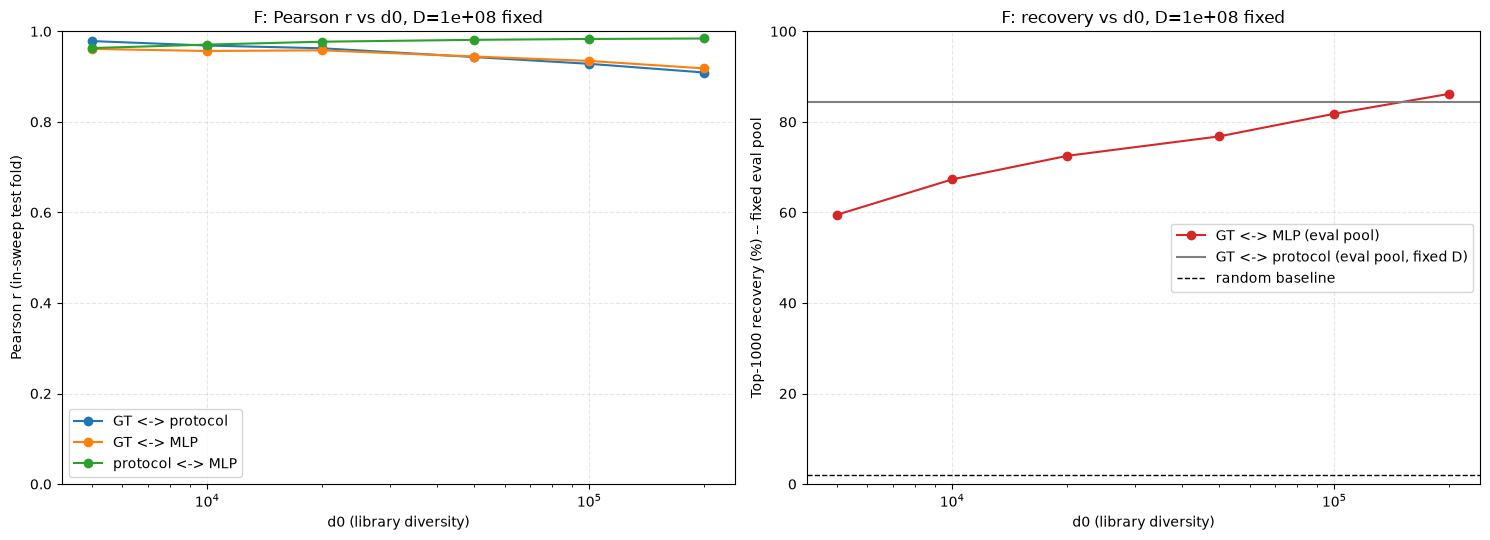

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
ax.plot(diversity_sweep_df["d0"], diversity_sweep_df["r_gt_protocol"], "o-", label="GT <-> protocol")
ax.plot(diversity_sweep_df["d0"], diversity_sweep_df["r_gt_mlp"], "o-", label="GT <-> MLP")
ax.plot(diversity_sweep_df["d0"], diversity_sweep_df["r_protocol_mlp"], "o-", label="protocol <-> MLP")
ax.set_xscale("log"); ax.set_ylim(0, 1)
ax.set_xlabel("d0 (library diversity)"); ax.set_ylabel("Pearson r (in-sweep test fold)")
ax.set_title(f"F: Pearson r vs d0, D={D_FIXED_DIVERSITY:.0e} fixed")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.3)

ax = axes[1]
ax.plot(diversity_sweep_df["d0"], 100 * diversity_sweep_df["rec_gt_mlp_eval"], "o-", color="tab:red", label="GT <-> MLP (eval pool)")
ax.axhline(100 * rec_gt_protocol_eval_f, color="gray", lw=1.5, ls="-", label="GT <-> protocol (eval pool, fixed D)")
ax.axhline(100 * K_TOPK / EVAL_POOL_SIZE, color="black", lw=1, ls="--", label="random baseline")
ax.set_xscale("log"); ax.set_ylim(0, 100)
ax.set_xlabel("d0 (library diversity)"); ax.set_ylabel(f"Top-{K_TOPK} recovery (%) -- fixed eval pool")
ax.set_title(f"F: recovery vs d0, D={D_FIXED_DIVERSITY:.0e} fixed")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


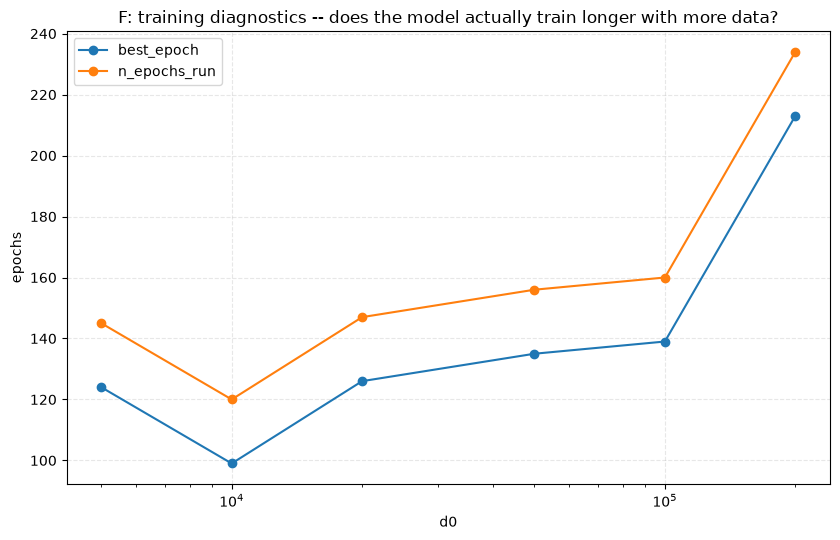

,d0,batch_size,val_mse,best_epoch,n_epochs_run,total_steps
0,5000,256,1.126021,124,145,1595
1,10000,256,0.773536,99,120,2760
2,20000,256,0.545218,126,147,6762
3,50000,595,0.380216,135,156,7800
4,100000,1190,0.282054,139,160,8000
5,200000,2380,0.219957,213,234,11700


In [29]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(diversity_sweep_df["d0"], diversity_sweep_df["best_epoch"], "o-", label="best_epoch")
ax.plot(diversity_sweep_df["d0"], diversity_sweep_df["n_epochs_run"], "o-", label="n_epochs_run")
ax.set_xscale("log")
ax.set_xlabel("d0"); ax.set_ylabel("epochs")
ax.set_title("F: training diagnostics -- does the model actually train longer with more data?")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()
diversity_sweep_df[["d0", "batch_size", "val_mse", "best_epoch", "n_epochs_run", "total_steps"]]


# Section G -- Influence of library diversity `d0`, `D` ADAPTIVE (scales with `d0`)

Companion to section F: same `mu`/`rho`/`T_viab`/`noise_viab`/`DIVERSITY_GRID`, but `D` now
scales WITH `d0` at a fixed `READS_PER_SEQ_TARGET=50,000` reads/sequence, capped at `D_MAX=1e9`
(a realistic single-NGS-run ceiling): `D(d0) = min(READS_PER_SEQ_TARGET * d0, D_MAX)`. Reads/
sequence stays flat at `50,000` up to `d0 = D_MAX / READS_PER_SEQ_TARGET = 20,000`; past that,
`D` is pinned at the ceiling and reads/sequence declines again, same shape as section F's
fixed-`D` case but starting from a deeper baseline. `protocol_eval` is reconstructed FRESH at
every `d0_val` (unlike section F's static one) since the adaptive `D_val` itself depends on `d0`.


In [30]:
records_g = []
base_key_g = jax.random.key(1)

for d0_val in tqdm(DIVERSITY_GRID, desc="G: diversity (d0) sweep, D adaptive"):
    pool_key_g  = jax.random.fold_in(base_key_g, d0_val)
    sequences_g = jax.random.randint(pool_key_g, shape=(d0_val, NUM_POSITIONS),
                                      minval=0, maxval=NUM_AMINO_ACIDS)
    N1_g  = MU_BASE * d0_val / RHO_BASE
    D_val_g = min(READS_PER_SEQ_TARGET * d0_val, D_MAX)

    protocol_g = ProtocolV3(multinomialNGS=True, N0=make_N0(N1_g), N1=N1_g,
            dilution_factor=10, sequences=sequences_g, D=D_val_g,
            F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
            noise_viab=NOISE_VIAB_BASE, noise_sel=0.5, T_sel=1, T_viab=T_VIAB_BASE,
            )
    protocol_g._rho = float(RHO_BASE)
    viab_score_g = np.array(protocol_g.compute_score(F_viab, J_viab))

    _bio_row_g, ngs_row_g = protocol_g.loop_DE()
    lambda0p_g, lambda2p_g, _lambda3p_g = (np.asarray(a) for a in ngs_row_g)
    target1_g = np.log((lambda2p_g + eps) / (lambda0p_g + eps))

    N1_eval_g = MU_BASE * EVAL_POOL_SIZE / RHO_BASE
    protocol_eval_g = ProtocolV3(multinomialNGS=True, N0=make_N0(N1_eval_g), N1=N1_eval_g,
            dilution_factor=10, sequences=eval_sequences, D=D_val_g,
            F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
            noise_viab=NOISE_VIAB_BASE, noise_sel=0.5, T_sel=1, T_viab=T_VIAB_BASE,
            )
    protocol_eval_g._rho = float(RHO_BASE)
    _bio_row_eg, ngs_row_eg = protocol_eval_g.loop_DE()
    lambda0p_eg, lambda2p_eg, _lambda3p_eg = (np.asarray(a) for a in ngs_row_eg)
    target1_eval_g = np.log((lambda2p_eg + eps) / (lambda0p_eg + eps))

    X_all_g = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(sequences_g)].reshape(d0_val, -1)
    idx_train_g, idx_test_g = train_test_split(np.arange(d0_val), test_size=0.3, random_state=0)
    X_train_full_g, X_test_g = X_all_g[idx_train_g], X_all_g[idx_test_g]
    viab_score_test_g = viab_score_g[idx_test_g]
    target1_train_g, target1_test_g = target1_g[idx_train_g], target1_g[idx_test_g]

    Xtr_g, ytr_g, Xva_g, yva_g = split_train_val(X_train_full_g, target1_train_g, val_frac=0.15, seed=0)
    batch_size_g = max(256, len(Xtr_g) // 50)
    model_g, val_mse_g, best_epoch_g, final_epoch_g, steps_per_epoch_g = train_shallow(
        Xtr_g, ytr_g, Xva_g, yva_g, epochs=300, patience=20, batch_size=batch_size_g)
    pred_test_g = np.asarray(predict_log_enrichment(model_g, jnp.asarray(X_test_g)))
    pred_eval_g = np.asarray(predict_log_enrichment(model_g, jnp.asarray(X_eval)))

    records_g.append(dict(
        d0=d0_val, D=D_val_g, batch_size=batch_size_g, val_mse=val_mse_g,
        best_epoch=best_epoch_g, n_epochs_run=final_epoch_g + 1,
        total_steps=steps_per_epoch_g * (final_epoch_g + 1),
        r_gt_protocol=pearson(viab_score_test_g, target1_test_g),
        r_gt_mlp=pearson(viab_score_test_g, pred_test_g),
        r_protocol_mlp=pearson(target1_test_g, pred_test_g),
        rec_gt_mlp_eval=topk_recovery(eval_viab_score, pred_eval_g, k=K_TOPK),
        r_gt_protocol_eval=pearson(eval_viab_score, target1_eval_g),
        rec_gt_protocol_eval=topk_recovery(eval_viab_score, target1_eval_g, k=K_TOPK),
    ))

diversity_sweep_adaptive_df = pd.DataFrame(records_g)
diversity_sweep_adaptive_df


G: diversity (d0) sweep, D adaptive: 100%|██████████| 6/6 [06:13<00:00, 62.19s/it]


,d0,D,batch_size,val_mse,best_epoch,n_epochs_run,total_steps,r_gt_protocol,r_gt_mlp,r_protocol_mlp,rec_gt_mlp_eval,r_gt_protocol_eval,rec_gt_protocol_eval
0,5000,2.500000e+08,256,1.166904,124,145,1595,0.985526,0.965003,0.964184,0.593,0.959843,0.844
1,10000,5.000000e+08,256,0.858889,99,120,2760,0.984102,0.969047,0.971789,0.659,0.969544,0.844
2,20000,1.000000e+09,256,0.627629,126,147,6762,0.986174,0.978353,0.979792,0.732,0.977090,0.844
3,50000,1.000000e+09,595,0.423525,233,254,12700,0.977259,0.977308,0.985663,0.790,0.977090,0.844
4,100000,1.000000e+09,1190,0.318256,167,188,9400,0.970126,0.973153,0.987157,0.824,0.977090,0.844
5,200000,1.000000e+09,2380,0.261061,248,269,13450,0.959800,0.965174,0.988558,0.852,0.977090,0.844


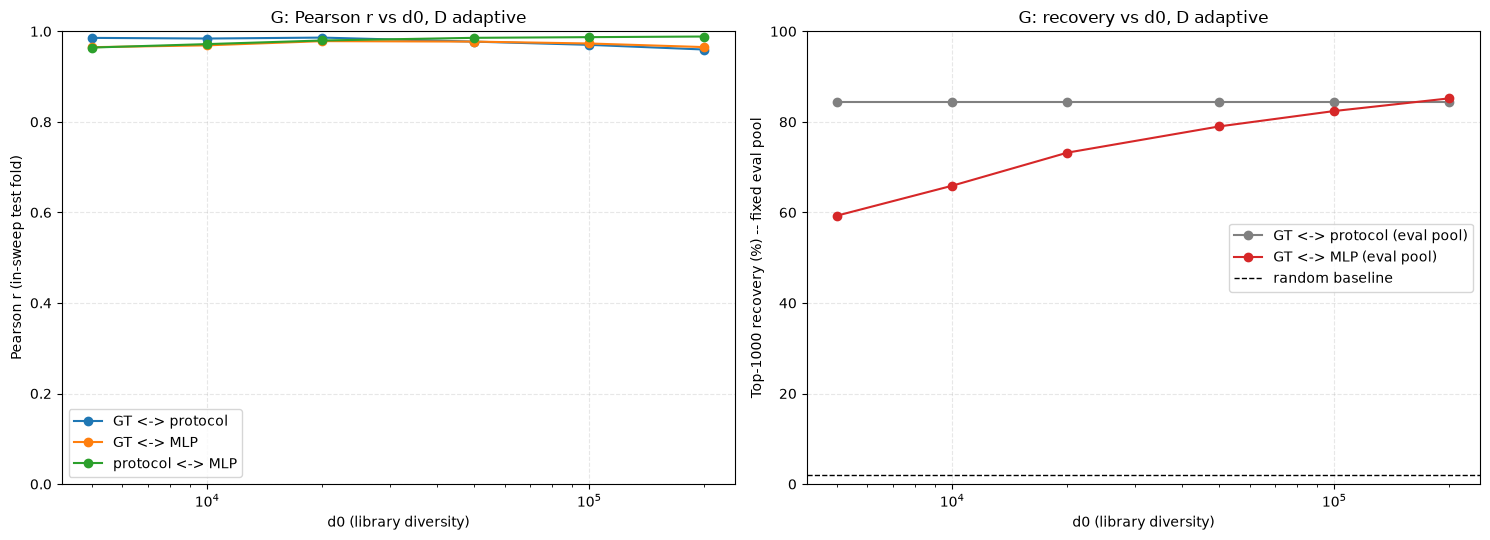

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
ax.plot(diversity_sweep_adaptive_df["d0"], diversity_sweep_adaptive_df["r_gt_protocol"], "o-", label="GT <-> protocol")
ax.plot(diversity_sweep_adaptive_df["d0"], diversity_sweep_adaptive_df["r_gt_mlp"], "o-", label="GT <-> MLP")
ax.plot(diversity_sweep_adaptive_df["d0"], diversity_sweep_adaptive_df["r_protocol_mlp"], "o-", label="protocol <-> MLP")
ax.set_xscale("log"); ax.set_ylim(0, 1)
ax.set_xlabel("d0 (library diversity)"); ax.set_ylabel("Pearson r (in-sweep test fold)")
ax.set_title("G: Pearson r vs d0, D adaptive")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.3)

ax = axes[1]
ax.plot(diversity_sweep_adaptive_df["d0"], 100 * diversity_sweep_adaptive_df["rec_gt_protocol_eval"], "o-", color="gray", label="GT <-> protocol (eval pool)")
ax.plot(diversity_sweep_adaptive_df["d0"], 100 * diversity_sweep_adaptive_df["rec_gt_mlp_eval"], "o-", color="tab:red", label="GT <-> MLP (eval pool)")
ax.axhline(100 * K_TOPK / EVAL_POOL_SIZE, color="black", lw=1, ls="--", label="random baseline")
ax.set_xscale("log"); ax.set_ylim(0, 100)
ax.set_xlabel("d0 (library diversity)"); ax.set_ylabel(f"Top-{K_TOPK} recovery (%) -- fixed eval pool")
ax.set_title("G: recovery vs d0, D adaptive")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


### G vs F: does compensating `D` for `d0` actually help?


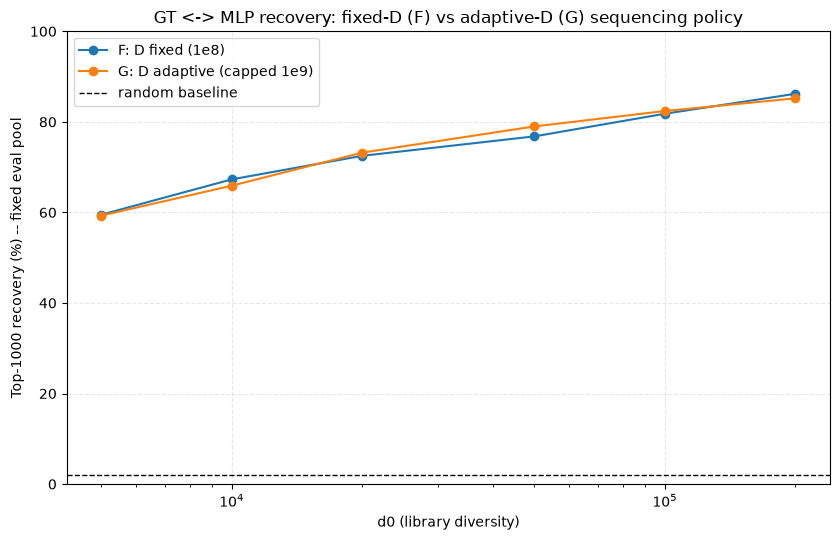

In [32]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(diversity_sweep_df["d0"], 100 * diversity_sweep_df["rec_gt_mlp_eval"], "o-", label="F: D fixed (1e8)")
ax.plot(diversity_sweep_adaptive_df["d0"], 100 * diversity_sweep_adaptive_df["rec_gt_mlp_eval"], "o-", label="G: D adaptive (capped 1e9)")
ax.axhline(100 * K_TOPK / EVAL_POOL_SIZE, color="black", lw=1, ls="--", label="random baseline")
ax.set_xscale("log"); ax.set_ylim(0, 100)
ax.set_xlabel("d0 (library diversity)"); ax.set_ylabel(f"Top-{K_TOPK} recovery (%) -- fixed eval pool")
ax.set_title("GT <-> MLP recovery: fixed-D (F) vs adaptive-D (G) sequencing policy")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


# Section H -- Does a deeper, structurally-informed `ProfileMLP` exploit diversity better?

Same recipe as section F (`D=D_FIXED_DIVERSITY` fixed, `mu=MU_BASE`, `noise_viab=NOISE_VIAB_BASE`,
same `DIVERSITY_GRID`) -- deliberately harmonized with section F's own parameters (unlike the
original `deeper_mlp/diversity_sweep_deeper_mlp.ipynb`, which used `D=5e8`/`noise_viab=3` while
claiming to reproduce `diversity_sweep.ipynb`'s `D=1e8`/`noise_viab=0.5` -- an inconsistency
flagged but left unresolved there, fixed here by construction). `ShallowProfileMLP` and
`DeepProfileMLP` (section 4) are trained on IDENTICAL data at every `d0` (same `Xtr`/`ytr`/`Xva`/
`yva`, same `batch_size`, same `seed=0`), so any difference is attributable to architecture alone.
Because the parameters now match section F exactly, `protocol_eval_f`/`target1_eval_f` (F's own
fixed-depth eval-pool reference) is reused directly here instead of rebuilding it.

Also builds `protocol_eval_matched` at `D_eval_matched = (D_FIXED_DIVERSITY / d0_val) *
EVAL_POOL_SIZE` per `d0_val` -- the SAME reads/sequence the training pool itself gets at that
point, the fairer "MLP vs raw NGS at the depth it was actually trained on" benchmark (section F's
`protocol_eval_f` is at a FIXED depth, not comparable in that specific way).


In [33]:
records_h = []
base_key_h = jax.random.key(1)

for d0_val in tqdm(DIVERSITY_GRID, desc="H: diversity (d0) sweep -- shallow vs deep"):
    pool_key_h  = jax.random.fold_in(base_key_h, d0_val)
    sequences_h = jax.random.randint(pool_key_h, shape=(d0_val, NUM_POSITIONS),
                                      minval=0, maxval=NUM_AMINO_ACIDS)
    N1_h = MU_BASE * d0_val / RHO_BASE

    protocol_h = ProtocolV3(multinomialNGS=True, N0=make_N0(N1_h), N1=N1_h,
            dilution_factor=10, sequences=sequences_h, D=D_FIXED_DIVERSITY,
            F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
            noise_viab=NOISE_VIAB_BASE, noise_sel=0.5, T_sel=1, T_viab=T_VIAB_BASE,
            )
    protocol_h._rho = float(RHO_BASE)
    viab_score_h = np.array(protocol_h.compute_score(F_viab, J_viab))

    _bio_row_h, ngs_row_h = protocol_h.loop_DE()
    lambda0p_h, lambda2p_h, _lambda3p_h = (np.asarray(a) for a in ngs_row_h)
    target1_h = np.log((lambda2p_h + eps) / (lambda0p_h + eps))

    D_eval_matched_h = (D_FIXED_DIVERSITY / d0_val) * EVAL_POOL_SIZE
    protocol_eval_matched_h = ProtocolV3(multinomialNGS=True, N0=make_N0(N1_eval_f), N1=N1_eval_f,
            dilution_factor=10, sequences=eval_sequences, D=D_eval_matched_h,
            F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
            noise_viab=NOISE_VIAB_BASE, noise_sel=0.5, T_sel=1, T_viab=T_VIAB_BASE,
            )
    protocol_eval_matched_h._rho = float(RHO_BASE)
    _bio_row_emh, ngs_row_emh = protocol_eval_matched_h.loop_DE()
    lambda0p_emh, lambda2p_emh, _lambda3p_emh = (np.asarray(a) for a in ngs_row_emh)
    target1_eval_matched_h = np.log((lambda2p_emh + eps) / (lambda0p_emh + eps))

    X_all_h = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(sequences_h)].reshape(d0_val, -1)
    idx_train_h, idx_test_h = train_test_split(np.arange(d0_val), test_size=0.3, random_state=0)
    X_train_full_h, X_test_h = X_all_h[idx_train_h], X_all_h[idx_test_h]
    viab_score_test_h = viab_score_h[idx_test_h]
    target1_train_h, target1_test_h = target1_h[idx_train_h], target1_h[idx_test_h]

    Xtr_h, ytr_h, Xva_h, yva_h = split_train_val(X_train_full_h, target1_train_h, val_frac=0.15, seed=0)
    batch_size_h = max(256, len(Xtr_h) // 50)

    rec_h = dict(d0=d0_val, batch_size=batch_size_h,
                 r_gt_protocol=pearson(viab_score_test_h, target1_test_h),
                 D_eval_matched=D_eval_matched_h,
                 r_gt_protocol_eval_matched=pearson(eval_viab_score, target1_eval_matched_h),
                 rec_gt_protocol_eval_matched=topk_recovery(eval_viab_score, target1_eval_matched_h, k=K_TOPK))

    model_ctors_h = {
        "shallow": lambda rngs: ShallowProfileMLP(input_dim=NUM_POSITIONS * NUM_AMINO_ACIDS, rngs=rngs),
        "deep":    lambda rngs: DeepProfileMLP(L=NUM_POSITIONS, A=NUM_AMINO_ACIDS, rngs=rngs),
    }
    for arch_name, ctor in model_ctors_h.items():
        model_h, val_mse_h, best_epoch_h, final_epoch_h, steps_per_epoch_h = train_model(
            ctor, Xtr_h, ytr_h, Xva_h, yva_h, epochs=300, patience=20, batch_size=batch_size_h)
        pred_test_h = np.asarray(predict_log_enrichment(model_h, jnp.asarray(X_test_h)))
        pred_eval_h = np.asarray(predict_log_enrichment(model_h, jnp.asarray(X_eval)))

        rec_h[f"r_gt_mlp_{arch_name}"] = pearson(viab_score_test_h, pred_test_h)
        rec_h[f"rec_gt_mlp_eval_{arch_name}"] = topk_recovery(eval_viab_score, pred_eval_h, k=K_TOPK)
        rec_h[f"rec_protocol_matched_mlp_{arch_name}"] = topk_recovery(target1_eval_matched_h, pred_eval_h, k=K_TOPK)
        rec_h[f"val_mse_{arch_name}"] = val_mse_h
        rec_h[f"best_epoch_{arch_name}"] = best_epoch_h
        rec_h[f"total_steps_{arch_name}"] = steps_per_epoch_h * (final_epoch_h + 1)

    records_h.append(rec_h)

arch_comparison_df = pd.DataFrame(records_h)
arch_comparison_df


H: diversity (d0) sweep -- shallow vs deep: 100%|██████████| 6/6 [08:47<00:00, 87.93s/it] 


,d0,batch_size,r_gt_protocol,D_eval_matched,r_gt_protocol_eval_matched,rec_gt_protocol_eval_matched,r_gt_mlp_shallow,rec_gt_mlp_eval_shallow,rec_protocol_matched_mlp_shallow,val_mse_shallow,best_epoch_shallow,total_steps_shallow,r_gt_mlp_deep,rec_gt_mlp_eval_deep,rec_protocol_matched_mlp_deep,val_mse_deep,best_epoch_deep,total_steps_deep
0,5000,256,0.978449,1.000000e+09,0.977090,0.844,0.961174,0.595,0.568,1.126021,124,1595,0.963764,0.658,0.613,0.850612,136,1727
1,10000,256,0.968634,5.000000e+08,0.969544,0.844,0.956581,0.673,0.638,0.773536,99,2760,0.961454,0.715,0.681,0.569163,171,4416
2,20000,256,0.962573,2.500000e+08,0.959843,0.844,0.958029,0.725,0.689,0.545218,126,6762,0.960921,0.754,0.713,0.435879,80,4646
3,50000,595,0.943171,1.000000e+08,0.943051,0.843,0.944370,0.768,0.731,0.380216,135,7800,0.944120,0.800,0.740,0.307559,76,4850
4,100000,1190,0.928233,5.000000e+07,0.927261,0.840,0.934601,0.818,0.765,0.282054,139,8000,0.930188,0.852,0.783,0.225316,86,5350
5,200000,2380,0.909051,2.500000e+07,0.908696,0.839,0.918085,0.862,0.789,0.219957,213,11700,0.916284,0.883,0.797,0.190950,71,4600


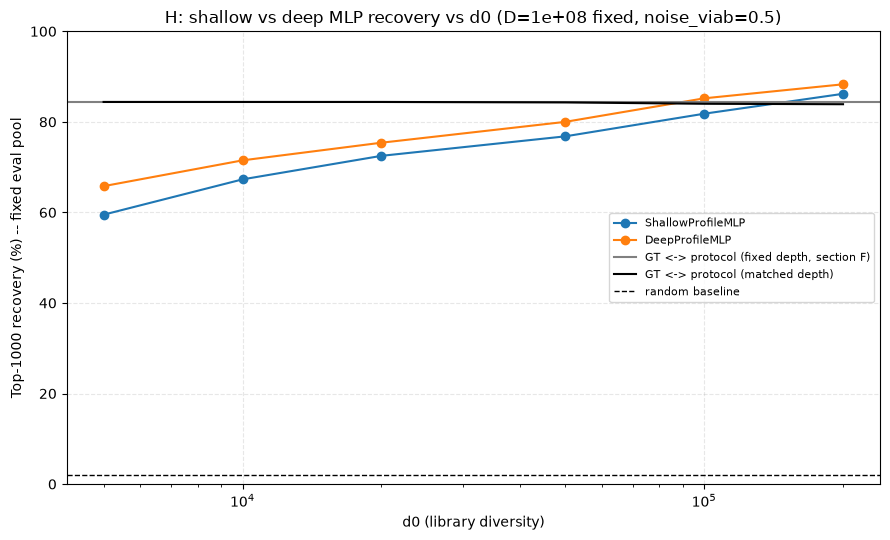

In [34]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(arch_comparison_df["d0"], 100 * arch_comparison_df["rec_gt_mlp_eval_shallow"], "o-", label="ShallowProfileMLP")
ax.plot(arch_comparison_df["d0"], 100 * arch_comparison_df["rec_gt_mlp_eval_deep"], "o-", label="DeepProfileMLP")
ax.axhline(100 * rec_gt_protocol_eval_f, color="gray", lw=1.5, ls="-", label="GT <-> protocol (fixed depth, section F)")
ax.plot(arch_comparison_df["d0"], 100 * arch_comparison_df["rec_gt_protocol_eval_matched"], "-", color="black", lw=1.5, label="GT <-> protocol (matched depth)")
ax.axhline(100 * K_TOPK / EVAL_POOL_SIZE, color="black", lw=1, ls="--", label="random baseline")
ax.set_xscale("log"); ax.set_ylim(0, 100)
ax.set_xlabel("d0 (library diversity)"); ax.set_ylabel(f"Top-{K_TOPK} recovery (%) -- fixed eval pool")
ax.set_title(f"H: shallow vs deep MLP recovery vs d0 (D={D_FIXED_DIVERSITY:.0e} fixed, noise_viab={NOISE_VIAB_BASE})")
ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


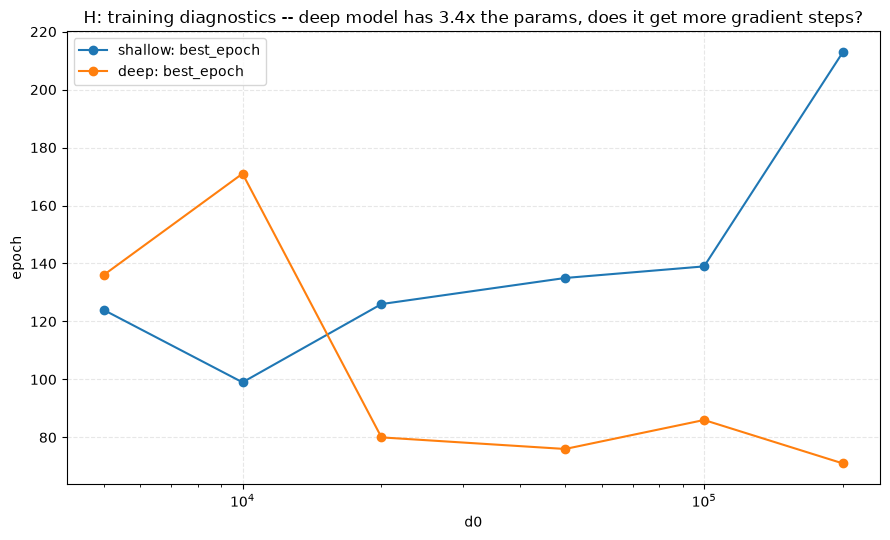

,d0,batch_size,val_mse_shallow,val_mse_deep,best_epoch_shallow,best_epoch_deep,total_steps_shallow,total_steps_deep
0,5000,256,1.126021,0.850612,124,136,1595,1727
1,10000,256,0.773536,0.569163,99,171,2760,4416
2,20000,256,0.545218,0.435879,126,80,6762,4646
3,50000,595,0.380216,0.307559,135,76,7800,4850
4,100000,1190,0.282054,0.225316,139,86,8000,5350
5,200000,2380,0.219957,0.190950,213,71,11700,4600


In [35]:
fig, ax = plt.subplots(figsize=(9, 5.5))
n_params_ratio = n_params_deep / n_params_shallow
ax.plot(arch_comparison_df["d0"], arch_comparison_df["best_epoch_shallow"], "o-", label="shallow: best_epoch")
ax.plot(arch_comparison_df["d0"], arch_comparison_df["best_epoch_deep"], "o-", label="deep: best_epoch")
ax.set_xscale("log")
ax.set_xlabel("d0"); ax.set_ylabel("epoch")
ax.set_title(f"H: training diagnostics -- deep model has {n_params_ratio:.1f}x the params, does it get more gradient steps?")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()
arch_comparison_df[["d0", "batch_size", "val_mse_shallow", "val_mse_deep",
                     "best_epoch_shallow", "best_epoch_deep", "total_steps_shallow", "total_steps_deep"]]


# Part 2 -- Selectivity phase

Part 1 (sections A-H) sweeps the VIABILITY channel only: `T_viab`/`noise_viab` control
`produce_capsids` (library -> production, `target1 = log((lambda2p+eps)/(lambda0p+eps))`),
scored against `F_viab`/`J_viab`. This part mirrors sections A/B/C/D on the SELECTIVITY channel
instead: `T_sel`/`noise_sel` control `selectivity()` (production -> selection,
`target2 = log((lambda3p+eps)/(lambda2p+eps))`), scored against `F_sel`/`J_sel` via
`compute_score(F_sel, J_sel)` -- the exact same GT<->measurement pairing pattern as
`F_viab`/`J_viab` <-> `target1`, confirmed against `ProtocolV3.selectivity()`'s own docstring
(`sequence_classesV1.py`, `scores = self.compute_score(self.F_sel, self.J_sel)`).

**Why this is expected to be noisier than Part 1.** `target2` compounds the ALREADY-noisy
`lambda2` population (itself the output of the whole viability step) with a SECOND, independent
noise draw (`noise_sel`/`T_sel`/Poisson in `selectivity()`) and a THIRD NGS read-depth sampling
step (`lambda3p`). `target1` only carries the first two of those. Every plot below keeps
`GT<->protocol` clearly visible (via the shared `plot_1d_sweep` helper's gray/black curves, same
as sections B-D), specifically so that extra noise is visible, not just the MLP's ability to
compensate for it -- section L closes with a direct viability-vs-selectivity overlay on the
identical `D` grid and pool to make the size of that gap explicit.

Reuses the SAME shared `d0=20,000` pool and `protocol`/`protocol_eval` objects from section 5:
sections A-D restored them to baseline before section E started, and sections E-H built their
OWN separate protocol objects, so `protocol`/`protocol_eval` are still sitting at that same
baseline here (`T_viab=T_VIAB_BASE`, `noise_viab=NOISE_VIAB_BASE`, `mu=MU_BASE`, `D=D_BASE`,
and -- newly named here -- `T_sel=T_SEL_BASE=1`, `noise_sel=NOISE_SEL_BASE=0.5`, already hardcoded
into every `ProtocolV3` constructor in this notebook, just not swept until now).
`T_SEL_GRID`/`NOISE_SEL_GRID` reuse `T_VIAB_GRID`/`NOISE_GRID`'s exact values.

**Not mirrored here** (kept out of scope for this part, can be added the same way later if
useful): section A's `(rho, N1)`-split sanity check (A.1) and no-noise ablation (A.3), and
selectivity analogs of the diversity/2D/architecture sections (E-H).


## Selectivity ground truth


In [36]:
sel_score_base = np.array(protocol.compute_score(F_sel, J_sel))
sel_score_test_base = sel_score_base[idx_test_base]
eval_sel_score = np.asarray(compute_score_array(eval_sequences, F_sel, J_sel))

T_SEL_BASE     = 1.0
NOISE_SEL_BASE = 0.5
T_SEL_GRID     = T_VIAB_GRID
NOISE_SEL_GRID = NOISE_GRID

print(f"sel GT score range (test fold): [{sel_score_test_base.min():.2f}, {sel_score_test_base.max():.2f}]")
print(f"sel GT score range (eval pool): [{eval_sel_score.min():.2f}, {eval_sel_score.max():.2f}]")
print(f"baseline (unchanged from sections A-D): T_sel={protocol._T_sel}  noise_sel={protocol.noise_sel}")


sel GT score range (test fold): [-17.01, 10.53]
sel GT score range (eval pool): [-19.23, 13.54]
baseline (unchanged from sections A-D): T_sel=1  noise_sel=0.5


## Shared harness for sections J-L (selectivity)

Same recipe as `run_1d_sweep` (sections B-D), but measures `target2` against `sel_score` instead
of `target1` against `viab_score`. Produces the same column schema, so the existing
`plot_1d_sweep` helper is reused as-is.


In [37]:
def run_1d_sweep_sel(param_name, grid, set_value, desc):
    """Selectivity-phase counterpart of run_1d_sweep: same mutate/reset/loop_DE/train recipe,
    but reads lambda3p (not lambda0p) to build target2, and compares against sel_score
    (F_sel/J_sel) instead of viab_score (F_viab/J_viab)."""
    records = []
    for val in tqdm(grid, desc=desc):
        set_value(protocol, val)
        protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
        set_value(protocol_eval, val)
        protocol_eval.lambda0 = jnp.full(protocol_eval.d0, protocol_eval.N0 / protocol_eval.d0)

        _bio_row, ngs_row = protocol.loop_DE()
        lambda0p, lambda2p, lambda3p = (np.asarray(a) for a in ngs_row)
        target2 = np.log((lambda3p + eps) / (lambda2p + eps))
        _bio_row_eval, ngs_row_eval = protocol_eval.loop_DE()
        lambda0p_eval, lambda2p_eval, lambda3p_eval = (np.asarray(a) for a in ngs_row_eval)
        target2_eval = np.log((lambda3p_eval + eps) / (lambda2p_eval + eps))
        target2_train, target2_test = target2[idx_train_base], target2[idx_test_base]

        Xtr, ytr, Xva, yva = split_train_val(X_train_full_base, target2_train, val_frac=0.15, seed=0)
        model, *_ = train_shallow(Xtr, ytr, Xva, yva, epochs=300, patience=20)
        pred_test = np.asarray(predict_log_enrichment(model, jnp.asarray(X_test_base)))
        pred_eval = np.asarray(predict_log_enrichment(model, jnp.asarray(X_eval)))

        records.append({
            param_name: val,
            "r_gt_protocol": pearson(sel_score_test_base, target2_test),
            "r_gt_mlp": pearson(sel_score_test_base, pred_test),
            "r_protocol_mlp": pearson(target2_test, pred_test),
            "rec_gt_protocol": topk_recovery(sel_score_test_base, target2_test, k=K_TOPK),
            "rec_gt_mlp": topk_recovery(sel_score_test_base, pred_test, k=K_TOPK),
            "rec_protocol_mlp": topk_recovery(target2_test, pred_test, k=K_TOPK),
            "rec_gt_mlp_eval": topk_recovery(eval_sel_score, pred_eval, k=K_TOPK),
            "r_gt_protocol_eval": pearson(eval_sel_score, target2_eval),
            "rec_gt_protocol_eval": topk_recovery(eval_sel_score, target2_eval, k=K_TOPK),
            "r_protocol_mlp_eval": pearson(target2_eval, pred_eval),
            "rec_protocol_mlp_eval": topk_recovery(target2_eval, pred_eval, k=K_TOPK),
        })
    return pd.DataFrame(records)


# Section I -- Influence of `mu` on the SELECTIVITY phase

Same mu sweep design as section A.2 (single `(rho, N1)` per `mu`, `rho=RHO_BASE`), but measuring
`target2`/`sel_score` instead of `target1`/`viab_score`. `T_sel`/`noise_sel` stay at their
baseline throughout -- only `mu` (via `N1`/`N0`/`rho`) is swept.


In [38]:
mu_sel_records = []
try:
    for mu in tqdm(MU_GRID, desc="I: mu sweep (selectivity, top-K recovery)"):
        N1_mu = mu * D0_BASE / RHO_BASE
        protocol.N1, protocol.N0, protocol._rho = float(N1_mu), float(make_N0(N1_mu)), float(RHO_BASE)
        protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)

        N1_eval_mu = mu * EVAL_POOL_SIZE / RHO_BASE
        protocol_eval.N1, protocol_eval.N0, protocol_eval._rho = (
            float(N1_eval_mu), float(make_N0(N1_eval_mu)), float(RHO_BASE))
        protocol_eval.lambda0 = jnp.full(protocol_eval.d0, protocol_eval.N0 / protocol_eval.d0)

        _bio_row, ngs_row = protocol.loop_DE()
        lambda0p, lambda2p, lambda3p = (np.asarray(a) for a in ngs_row)
        target2_mu = np.log((lambda3p + eps) / (lambda2p + eps))
        target2_train_mu, target2_test_mu = target2_mu[idx_train_base], target2_mu[idx_test_base]

        _bio_row_ev, ngs_row_ev = protocol_eval.loop_DE()
        lambda0p_ev, lambda2p_ev, lambda3p_ev = (np.asarray(a) for a in ngs_row_ev)
        target2_eval_mu = np.log((lambda3p_ev + eps) / (lambda2p_ev + eps))

        Xtr_mu, ytr_mu, Xva_mu, yva_mu = split_train_val(X_train_full_base, target2_train_mu,
                                                          val_frac=0.15, seed=0)
        model_mu, *_ = train_shallow(Xtr_mu, ytr_mu, Xva_mu, yva_mu, epochs=300, patience=20)
        pred_mu = np.asarray(predict_log_enrichment(model_mu, jnp.asarray(X_test_base)))
        pred_eval_mu = np.asarray(predict_log_enrichment(model_mu, jnp.asarray(X_eval)))

        mu_sel_records.append(dict(
            mu=mu,
            r_gt_protocol=pearson(sel_score_test_base, target2_test_mu),
            r_gt_mlp=pearson(sel_score_test_base, pred_mu),
            r_protocol_mlp=pearson(target2_test_mu, pred_mu),
            rec_gt_protocol=topk_recovery(sel_score_test_base, target2_test_mu, k=K_TOPK),
            rec_gt_mlp=topk_recovery(sel_score_test_base, pred_mu, k=K_TOPK),
            rec_protocol_mlp=topk_recovery(target2_test_mu, pred_mu, k=K_TOPK),
            r_gt_protocol_eval=pearson(eval_sel_score, target2_eval_mu),
            rec_gt_protocol_eval=topk_recovery(eval_sel_score, target2_eval_mu, k=K_TOPK),
            rec_gt_mlp_eval=topk_recovery(eval_sel_score, pred_eval_mu, k=K_TOPK),
            rec_protocol_mlp_eval=topk_recovery(target2_eval_mu, pred_eval_mu, k=K_TOPK),
        ))
finally:
    protocol.N1, protocol.N0, protocol._rho = N1_BASE, make_N0(N1_BASE), RHO_BASE
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
    protocol_eval.N1, protocol_eval.N0, protocol_eval._rho = N1_EVAL_BASE, make_N0(N1_EVAL_BASE), RHO_BASE
    protocol_eval.lambda0 = jnp.full(protocol_eval.d0, protocol_eval.N0 / protocol_eval.d0)

mu_sweep_sel_df = pd.DataFrame(mu_sel_records)
mu_sweep_sel_df


I: mu sweep (selectivity, top-K recovery): 100%|██████████| 8/8 [05:56<00:00, 44.52s/it]


,mu,r_gt_protocol,r_gt_mlp,r_protocol_mlp,rec_gt_protocol,rec_gt_mlp,rec_protocol_mlp,r_gt_protocol_eval,rec_gt_protocol_eval,rec_gt_mlp_eval,rec_protocol_mlp_eval
0,0.01,0.039153,0.160890,0.021309,0.162,0.192,0.157,0.061424,0.024,0.039,0.031
1,0.10,0.197472,0.367578,0.088814,0.211,0.294,0.175,0.199628,0.081,0.093,0.034
2,0.30,0.323702,0.448861,0.179161,0.309,0.354,0.195,0.318497,0.248,0.137,0.085
3,1.00,0.558358,0.677589,0.570030,0.595,0.645,0.447,0.522501,0.516,0.463,0.356
4,3.00,0.749252,0.775723,0.887125,0.834,0.806,0.742,0.701285,0.688,0.626,0.570
5,10.00,0.809431,0.819708,0.944516,0.835,0.845,0.778,0.765700,0.691,0.673,0.608
6,30.00,0.838801,0.845273,0.944980,0.848,0.834,0.798,0.803060,0.659,0.614,0.583
7,100.00,0.867589,0.877554,0.947307,0.828,0.814,0.789,0.834400,0.626,0.579,0.598


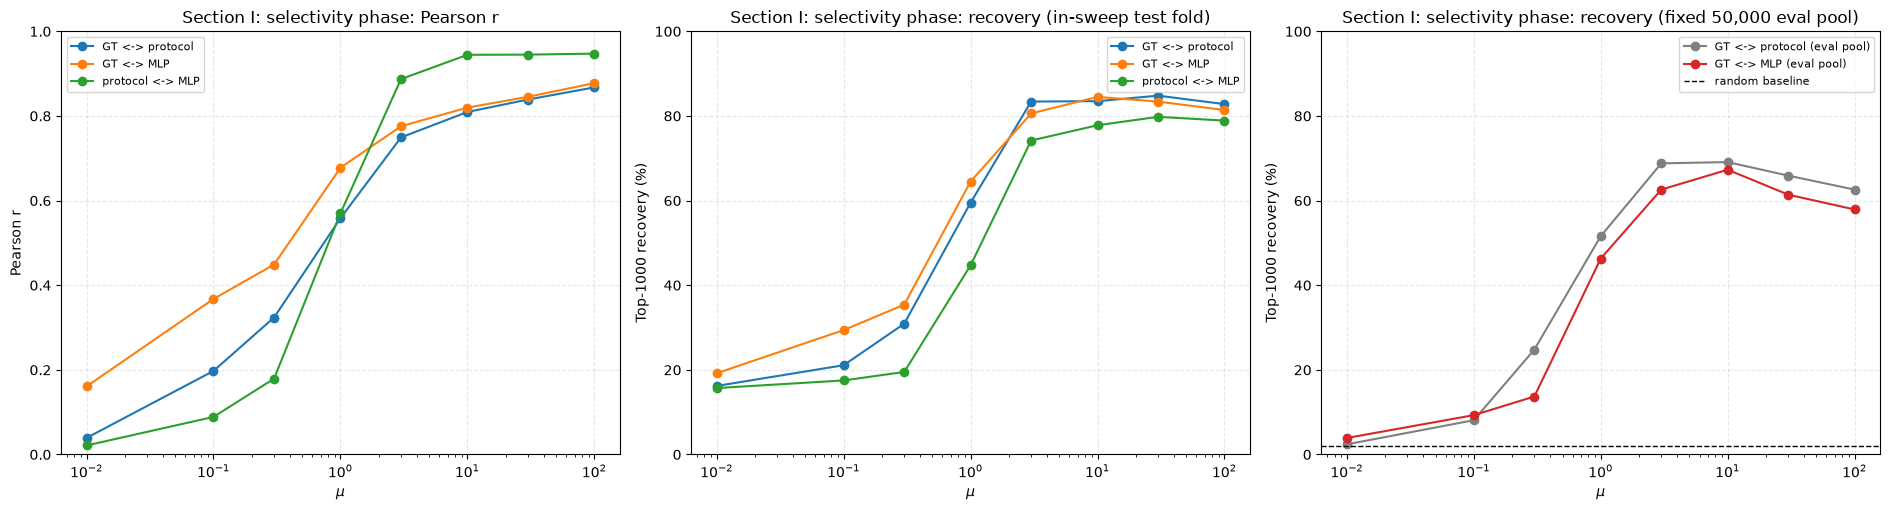

In [39]:
plot_1d_sweep(mu_sweep_sel_df, "mu", r"$\mu$", "Section I: selectivity phase")


# Section J -- Influence of `T_sel` (selectivity temperature)

Direct selectivity analog of section B: `rate = lambda2 * exp(noisy_scores / T_sel)` in
`selectivity()` -- same sharp-vs-flat trade-off as `T_viab`, applied one step downstream. `mu`,
`T_viab`, `noise_viab`, `noise_sel` stay at baseline throughout.


In [40]:
original_T_sel = protocol._T_sel
try:
    T_sel_sweep_df = run_1d_sweep_sel("T_sel", T_SEL_GRID,
        lambda p, v: setattr(p, "_T_sel", float(v)), "J: T_sel sweep")
finally:
    protocol._T_sel = original_T_sel
    protocol_eval._T_sel = original_T_sel

T_sel_sweep_df


J: T_sel sweep: 100%|██████████| 15/15 [12:42<00:00, 50.86s/it]


,T_sel,r_gt_protocol,r_gt_mlp,r_protocol_mlp,rec_gt_protocol,rec_gt_mlp,rec_protocol_mlp,rec_gt_mlp_eval,r_gt_protocol_eval,rec_gt_protocol_eval,r_protocol_mlp_eval,rec_protocol_mlp_eval
0,0.1,0.693762,0.705257,0.896931,0.492,0.564,0.755,0.109,NaN,0.021,NaN,0.015
1,0.2,0.720923,0.743357,0.919146,0.632,0.664,0.777,0.224,0.697382,0.151,0.918751,0.474
2,0.3,0.738014,0.746540,0.931345,0.741,0.755,0.793,0.378,0.711118,0.301,0.930200,0.556
3,0.4,0.750733,0.759320,0.940025,0.818,0.803,0.809,0.472,0.719531,0.431,0.935694,0.555
4,0.5,0.761903,0.774081,0.945385,0.835,0.803,0.798,0.535,0.727312,0.543,0.938820,0.594
5,0.6,0.767885,0.773490,0.944675,0.848,0.834,0.808,0.570,0.734551,0.610,0.941662,0.568
6,0.7,0.782420,0.788682,0.946678,0.852,0.839,0.805,0.612,0.741513,0.643,0.940093,0.584
7,0.8,0.790182,0.795598,0.945766,0.844,0.837,0.785,0.614,0.750012,0.661,0.939692,0.586
8,0.9,0.798767,0.812165,0.945145,0.845,0.847,0.792,0.645,0.758167,0.679,0.937142,0.597
9,1.0,0.806759,0.811476,0.942529,0.849,0.844,0.781,0.656,0.765832,0.685,0.937302,0.594


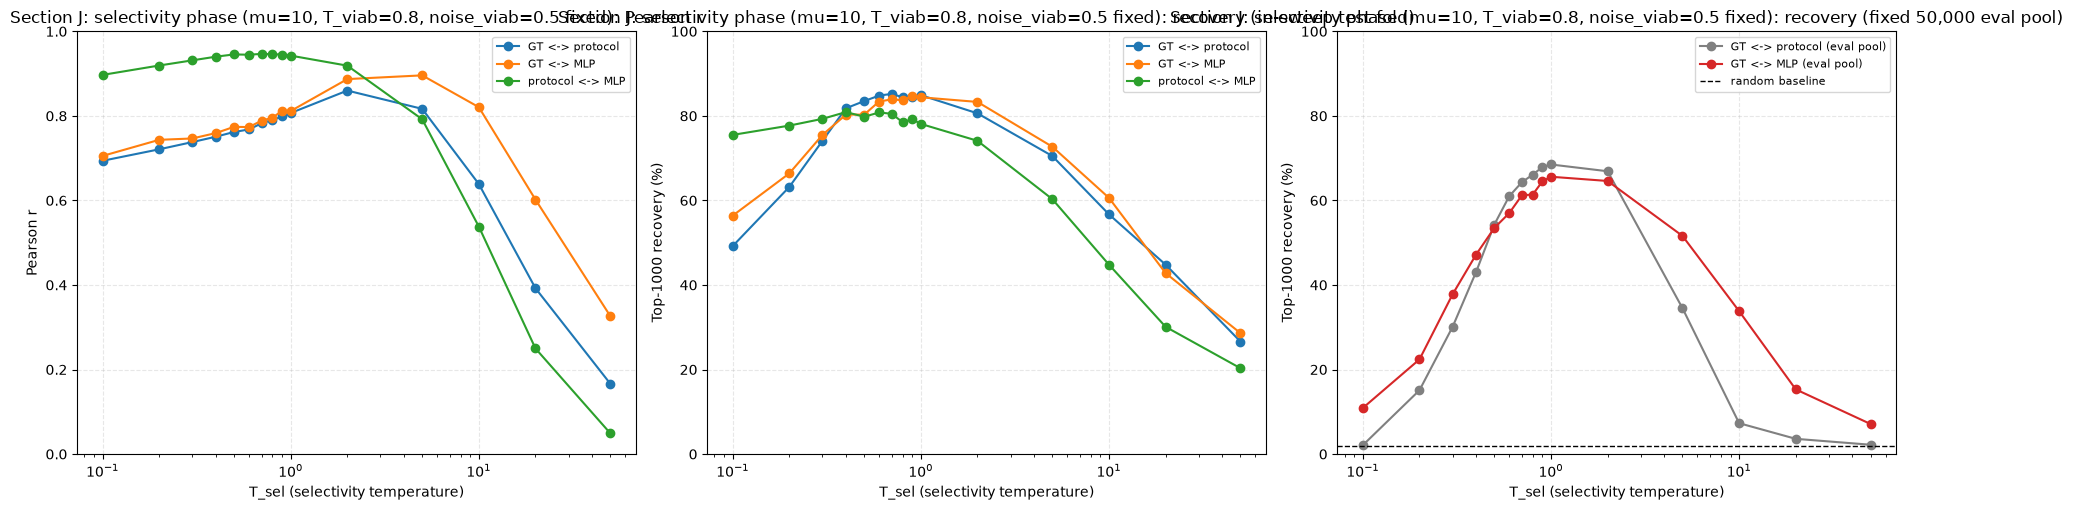

In [41]:
plot_1d_sweep(T_sel_sweep_df, "T_sel", "T_sel (selectivity temperature)",
              f"Section J: selectivity phase (mu={MU_BASE}, T_viab={T_VIAB_BASE}, noise_viab={NOISE_VIAB_BASE} fixed)")


# Section K -- Influence of `noise_sel` (selectivity-step noise)

Direct selectivity analog of section C: `noisy_scores = scores + noise_sel * Z` in
`selectivity()`. Same denoising-signature question as section C, one step downstream and on top
of whatever noise the viability step (held at baseline `noise_viab=NOISE_VIAB_BASE`) already put
into `lambda2`.


In [42]:
original_noise_sel = protocol.noise_sel
try:
    noise_sel_sweep_df = run_1d_sweep_sel("noise_sel", NOISE_SEL_GRID,
        lambda p, v: setattr(p, "noise_sel", float(v)), "K: noise_sel sweep")
finally:
    protocol.noise_sel = original_noise_sel
    protocol_eval.noise_sel = original_noise_sel

noise_sel_sweep_df


K: noise_sel sweep: 100%|██████████| 8/8 [06:40<00:00, 50.03s/it]


,noise_sel,r_gt_protocol,r_gt_mlp,r_protocol_mlp,rec_gt_protocol,rec_gt_mlp,rec_protocol_mlp,rec_gt_mlp_eval,r_gt_protocol_eval,rec_gt_protocol_eval,r_protocol_mlp_eval,rec_protocol_mlp_eval
0,0.00,0.818944,0.827687,0.959464,0.907,0.865,0.837,0.699,0.777281,0.783,0.951857,0.680
1,0.10,0.819275,0.820191,0.958530,0.898,0.862,0.831,0.692,0.775908,0.768,0.952919,0.685
2,0.25,0.816511,0.823839,0.956751,0.889,0.865,0.819,0.675,0.774234,0.751,0.948892,0.651
3,0.50,0.805659,0.817416,0.941991,0.848,0.847,0.791,0.661,0.766862,0.687,0.937198,0.608
4,1.00,0.777544,0.802838,0.901875,0.768,0.798,0.696,0.602,0.738180,0.541,0.895482,0.459
5,2.00,0.686418,0.740528,0.777533,0.630,0.707,0.550,0.502,0.652053,0.347,0.779613,0.278
6,4.00,0.501143,0.612724,0.555407,0.445,0.546,0.363,0.330,0.472669,0.177,0.557233,0.109
7,8.00,0.296604,0.417700,0.372948,0.300,0.363,0.238,0.188,0.277009,0.067,0.385241,0.083


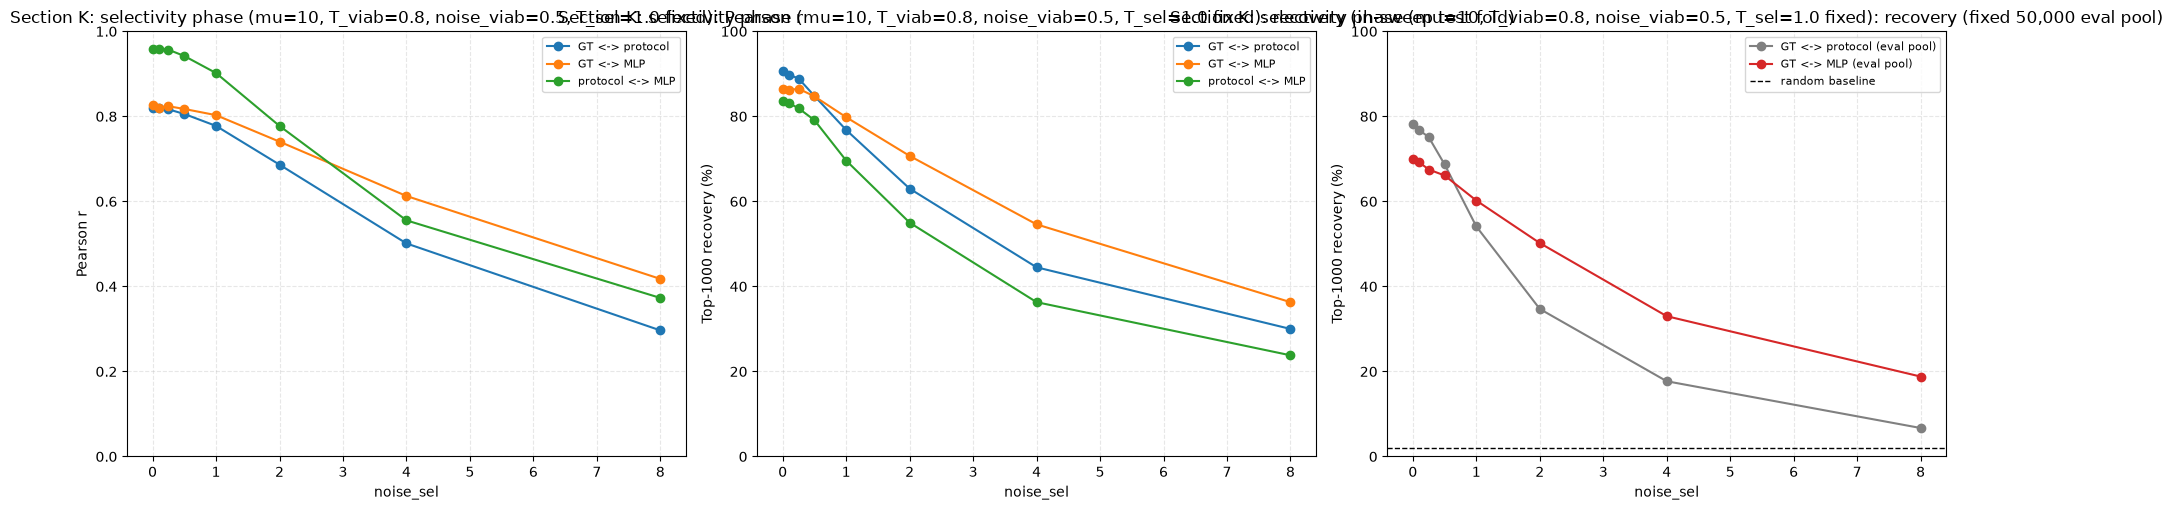

In [43]:
plot_1d_sweep(noise_sel_sweep_df, "noise_sel", "noise_sel",
              f"Section K: selectivity phase (mu={MU_BASE}, T_viab={T_VIAB_BASE}, noise_viab={NOISE_VIAB_BASE}, T_sel={T_SEL_BASE} fixed)",
              logx=False)


# Section L -- Influence of `D` on the SELECTIVITY phase, and a direct noise comparison

`D` sets the read depth at ALL THREE NGS checkpoints simultaneously (`lambda0p`/`lambda2p`/
`lambda3p`), so this section's `D_GRID` is the exact same grid AND the exact same physical
parameter as section D's -- the cleanest apples-to-apples comparison in this notebook. The closing
plot overlays section D's `GT<->protocol` curve (viability, `target1`) against this section's
(selectivity, `target2`) at every `D`, on the same fixed eval pool -- the direct answer to "how
much noisier is the raw selectivity protocol signal than the raw viability one".


In [44]:
original_D_l = protocol.D
try:
    D_sweep_sel_df = run_1d_sweep_sel("D", D_GRID,
        lambda p, v: setattr(p, "D", float(v)), "L: D sweep (selectivity)")
finally:
    protocol.D = original_D_l
    protocol_eval.D = original_D_l

D_sweep_sel_df


L: D sweep (selectivity): 100%|██████████| 9/9 [08:54<00:00, 59.36s/it]


,D,r_gt_protocol,r_gt_mlp,r_protocol_mlp,rec_gt_protocol,rec_gt_mlp,rec_protocol_mlp,rec_gt_mlp_eval,r_gt_protocol_eval,rec_gt_protocol_eval,r_protocol_mlp_eval,rec_protocol_mlp_eval
0,1.000000e+06,0.462429,0.463465,0.866725,0.580,0.619,0.557,0.428,0.421477,0.393,0.851291,0.538
1,3.000000e+06,0.520257,0.523498,0.892569,0.658,0.669,0.645,0.479,0.475218,0.460,0.879964,0.577
2,1.000000e+07,0.586744,0.615143,0.916920,0.712,0.744,0.744,0.511,0.537556,0.511,0.900111,0.569
3,3.000000e+07,0.639524,0.652834,0.924282,0.770,0.792,0.754,0.541,0.591138,0.567,0.911099,0.574
4,1.000000e+08,0.699959,0.729380,0.933689,0.810,0.805,0.764,0.579,0.653790,0.600,0.921269,0.594
5,3.000000e+08,0.754887,0.767264,0.939969,0.820,0.834,0.761,0.639,0.708588,0.652,0.931495,0.596
6,1.000000e+09,0.807157,0.815950,0.943667,0.837,0.843,0.779,0.648,0.766266,0.685,0.938358,0.595
7,3.000000e+09,0.853445,0.863835,0.948238,0.868,0.856,0.804,0.670,0.814875,0.718,0.941452,0.622
8,1.000000e+10,0.891821,0.901871,0.949557,0.869,0.859,0.815,0.668,0.861585,0.720,0.944732,0.603


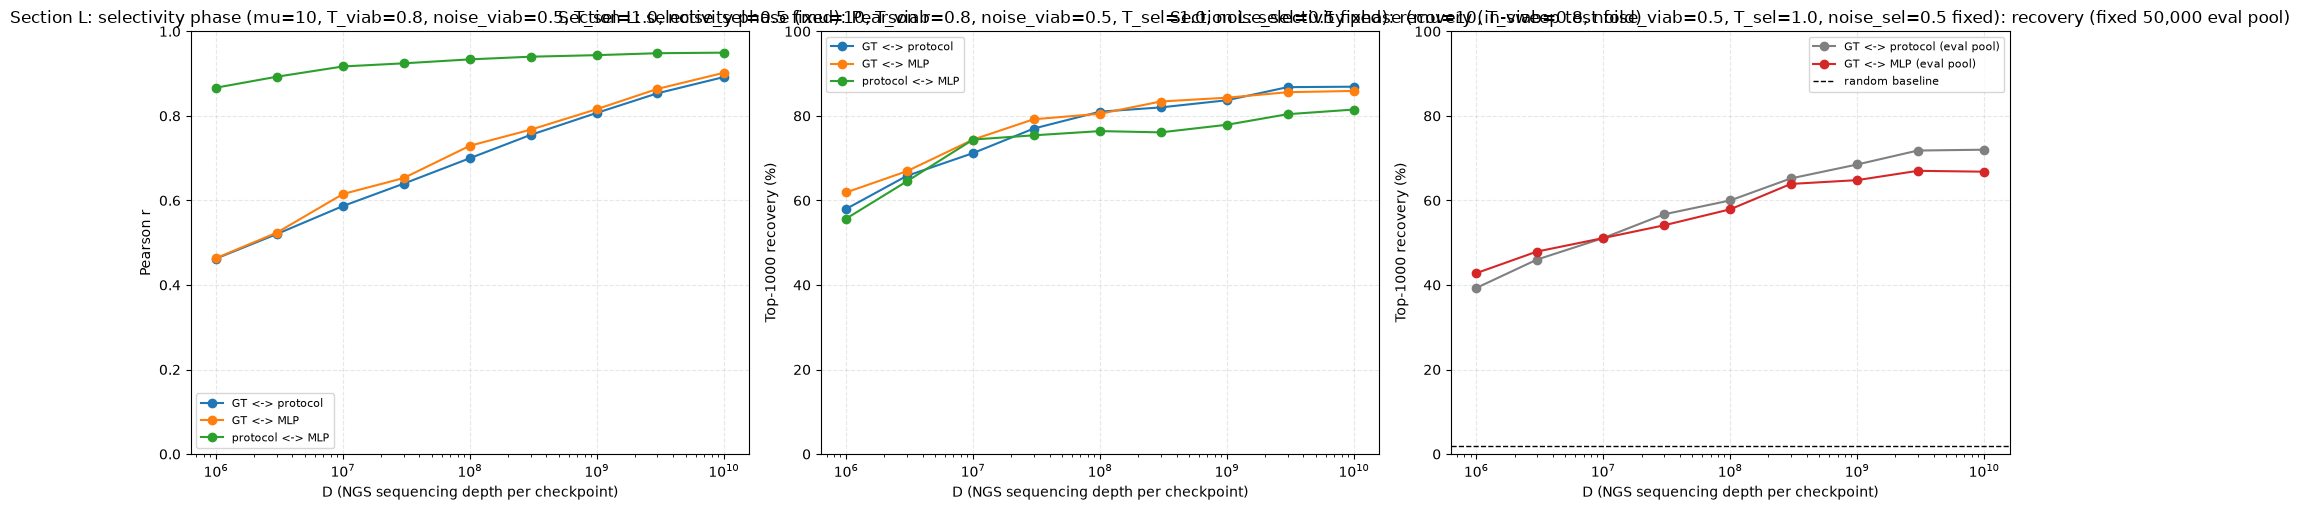

In [45]:
plot_1d_sweep(D_sweep_sel_df, "D", "D (NGS sequencing depth per checkpoint)",
              f"Section L: selectivity phase (mu={MU_BASE}, T_viab={T_VIAB_BASE}, noise_viab={NOISE_VIAB_BASE}, "
              f"T_sel={T_SEL_BASE}, noise_sel={NOISE_SEL_BASE} fixed)")


### Viability vs selectivity: the raw protocol signal, same `D`, same pool


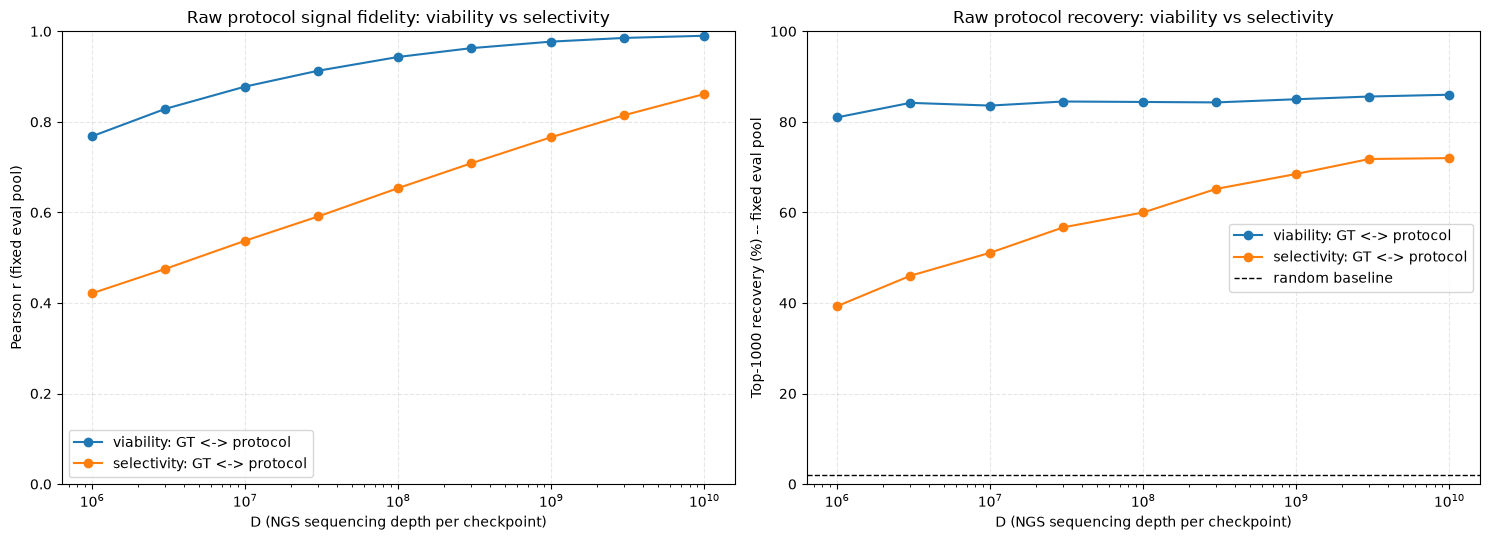

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
ax.plot(D_sweep_df["D"], D_sweep_df["r_gt_protocol_eval"], "o-", color="tab:blue", label="viability: GT <-> protocol")
ax.plot(D_sweep_sel_df["D"], D_sweep_sel_df["r_gt_protocol_eval"], "o-", color="tab:orange", label="selectivity: GT <-> protocol")
ax.set_xscale("log"); ax.set_ylim(0, 1)
ax.set_xlabel("D (NGS sequencing depth per checkpoint)"); ax.set_ylabel("Pearson r (fixed eval pool)")
ax.set_title("Raw protocol signal fidelity: viability vs selectivity")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.3)

ax = axes[1]
ax.plot(D_sweep_df["D"], 100 * D_sweep_df["rec_gt_protocol_eval"], "o-", color="tab:blue", label="viability: GT <-> protocol")
ax.plot(D_sweep_sel_df["D"], 100 * D_sweep_sel_df["rec_gt_protocol_eval"], "o-", color="tab:orange", label="selectivity: GT <-> protocol")
ax.axhline(100 * K_TOPK / EVAL_POOL_SIZE, color="black", lw=1, ls="--", label="random baseline")
ax.set_xscale("log"); ax.set_ylim(0, 100)
ax.set_xlabel("D (NGS sequencing depth per checkpoint)"); ax.set_ylabel(f"Top-{K_TOPK} recovery (%) -- fixed eval pool")
ax.set_title("Raw protocol recovery: viability vs selectivity")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.3)

fig.tight_layout()
plt.show()


## How to read this notebook

- **Sections A-D** (mu, `T_viab`, `noise_viab`, `D`) share the literal same `20,000`-sequence
  pool in sequence -- a difference between, say, section B's and section C's curves is
  attributable to `T_viab` vs `noise_viab` alone, not to a different random population.
- **Pearson `r` vs top-K recovery need not peak/decline at the same point** (`T_viab_sweep.ipynb`'s
  original finding, section B here): `r` is a global ranking measure, recovery only cares about
  the extreme tail. Pick by `r` if the downstream use needs the whole ranking, by recovery if only
  the very best candidates matter (as in `directed_evolution_loop/DE_loopV1.ipynb`).
- **Denoising signature** (sections A.3, C, E, K): if `GT <-> MLP` stays ABOVE `GT <-> protocol`
  as noise grows, the MLP is genuinely denoising via redundancy in its training fold, not just
  mirroring the noisy label it was trained on.
- **Sections F/G/H all share `DIVERSITY_GRID` and the `N0=150*N1` cap** -- their `GT<->protocol`
  curves are now directly comparable to each other in a way the original three separate notebooks
  never quite were (see the title cell's "two things this run resolves").
- **Section H's `best_epoch`/`total_steps` diagnostics** answer whether `DeepProfileMLP`'s edge (if
  any) over `ShallowProfileMLP` comes from genuinely exploiting more data, or just from more
  gradient steps at the same data size.
- **Part 2 (sections I-L)** mirrors A/B/C/D on the selectivity channel (`T_sel`/`noise_sel`/`D`
  vs `target2`/`sel_score`, `F_sel`/`J_sel`) instead of the viability one -- section L's closing
  plot makes the expected extra noise (an additional independent noise draw plus an additional
  NGS read-depth step stacked on top of the viability step's own noise) directly visible: compare
  `GT<->protocol` in Part 1 section D against Part 2 section L at the same `D`, same pool.
